# Step 2. 전처리 + 피처 엔지니어링 + 탐색적 분석

| 항목 | 내용 |
|------|------|
| **분석 기간** | 2016-01-01 ~ 2025-12-31 |
| **포트폴리오 자산** | 30종 (ETF 22 + 개별주 8) |
| **외부 지표** | 12종 (원자재·VIX·달러·암호화폐) |
| **FRED 매크로** | 8종 (금리·스프레드·고용·성장) |
| **파생 변수** | 15개 Feature Engineering |
| **최종 산출물** | df_reg_v2.csv (확장 회귀 데이터셋) |

In [4]:
# ── Imports & Data Loading ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, pathlib

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

BASE = pathlib.Path('.')
DATA = BASE / 'data'
IMG  = BASE / 'images'
IMG.mkdir(exist_ok=True)

# 데이터 로드
portfolio_prices = pd.read_csv(DATA / 'portfolio_prices.csv', index_col=0, parse_dates=True)
external_prices  = pd.read_csv(DATA / 'external_prices.csv',  index_col=0, parse_dates=True)
fred_data        = pd.read_csv(DATA / 'fred_data.csv',        index_col=0, parse_dates=True)

print(f'portfolio_prices : {portfolio_prices.shape}')
print(f'external_prices  : {external_prices.shape}')
print(f'fred_data        : {fred_data.shape}')

# ── 자산 그룹 정의 ──
INDEX_ETF  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
BOND_ETF   = ['TLT', 'AGG', 'SHY', 'TIP']
ALT_ETF    = ['GLD', 'DBC']
SECTOR_ETF = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
STOCKS     = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']

EQUITY_TICKERS = INDEX_ETF + SECTOR_ETF + STOCKS  # 24 items
ALL_TICKERS    = INDEX_ETF + BOND_ETF + ALT_ETF + SECTOR_ETF + STOCKS  # 30 items

print(f'\nEQUITY_TICKERS : {len(EQUITY_TICKERS)}개')
print(f'ALL_TICKERS    : {len(ALL_TICKERS)}개')

portfolio_prices : (2609, 30)
external_prices  : (2609, 12)
fred_data        : (2609, 8)

EQUITY_TICKERS : 24개
ALL_TICKERS    : 30개


## EDA

### 1. 기초통계

In [5]:
# ── 원본 데이터 기초 통계 & 결측치 ───────────────────────────────
port = pd.read_csv(DATA / 'portfolio_prices.csv', index_col=0, parse_dates=True)
ext  = pd.read_csv(DATA / 'external_prices.csv',  index_col=0, parse_dates=True)
fred = pd.read_csv(DATA / 'fred_data.csv',         index_col=0, parse_dates=True)

for name, df in [('포트폴리오 (30개)', port), ('외부 지표 (12개)', ext), ('FRED (8개)', fred)]:
    print(f'\n{"=" * 55}')
    print(f'  {name}')
    print(f'  shape : {df.shape}  |  기간 : {df.index[0].date()} ~ {df.index[-1].date()}')
    print(f'  결측치: {df.isnull().sum().sum()}개')
    stats = df.describe().T[['mean', 'std', 'min', 'max']]
    stats['skewness'] = df.skew()
    stats['kurtosis'] = df.kurt()
    display(stats.round(2))


  포트폴리오 (30개)
  shape : (2609, 30)  |  기간 : 2016-01-01 ~ 2025-12-31
  결측치: 0개


,mean,std,min,max,skewness,kurtosis
SPY,353.70,136.73,154.56,688.50,0.60,-0.59
QQQ,281.18,141.08,89.47,634.15,0.58,-0.65
IWM,164.81,39.63,83.12,256.48,0.11,-0.95
EFA,60.75,12.71,38.09,96.57,0.64,-0.08
EEM,38.26,6.27,22.63,55.22,0.25,0.07
TLT,101.99,16.35,74.54,144.32,0.85,-0.32
AGG,90.82,5.70,81.31,101.33,0.31,-1.28
SHY,73.69,3.23,69.37,82.13,0.62,-0.33
TIP,97.43,8.17,82.58,111.77,-0.07,-1.38
GLD,171.24,60.32,102.89,416.74,1.69,2.90



  외부 지표 (12개)
  shape : (2609, 12)  |  기간 : 2016-01-01 ~ 2025-12-31
  결측치: 0개


,mean,std,min,max,skewness,kurtosis
CL=F,63.61,17.51,-37.63,123.70,0.22,0.81
GC=F,1831.55,667.31,1073.90,4529.10,1.67,2.81
SI=F,22.53,8.08,11.73,77.37,2.24,7.96
BTC-USD,30289.91,32084.90,364.33,124752.53,1.20,0.43
ETH-USD,1431.65,1283.93,84.31,4831.35,0.70,-0.78
^VIX,18.46,7.29,9.14,82.69,2.55,12.47
DX-Y.NYB,98.52,5.02,88.59,114.11,0.36,-0.44
^VIX9D,17.63,8.89,7.10,106.66,3.37,20.59
^VIX3M,20.45,6.44,11.85,72.98,1.96,7.89
^VIX6M,21.83,5.69,13.75,61.11,1.30,2.88



  FRED (8개)
  shape : (2609, 8)  |  기간 : 2016-01-01 ~ 2025-12-31
  결측치: 0개


,mean,std,min,max,skewness,kurtosis
BAMLH0A0HYM2,4.11,1.17,2.59,10.87,1.84,4.19
T10Y2Y,0.38,0.58,-1.08,1.59,-0.29,-0.56
ICSA,364690.30,549447.36,190000.00,6137000.00,7.01,58.63
WEI,2.17,2.47,-8.11,10.57,-0.58,5.16
SAHMREALTIME,0.56,1.65,-0.37,9.50,3.56,12.78
DGS10,2.70,1.17,0.52,4.98,0.07,-1.15
CPIAUCSL,275.51,28.89,237.34,326.03,0.37,-1.43
UNRATE,4.58,1.72,3.40,14.80,3.70,15.75


[외부지표]  
1. CL=F 음수 : 2020년 WTI 원유 가격 마이너스 사건
- 발생일: 2020년 4월 20일
- 가격: 배럴당 –37.63달러(종가 기준)
- 원유 종류: WTI(서부텍사스산중질유)
- 거래소: 뉴욕상업거래소
- 주요 원인: 수요 급감, 저장시설 포화, 선물 만기 압박

[FRED]  
1. T10Y2Y (장단기 금리차) : 음수이면 경기 침체 신호  
2. WEI (경제 활동 종합 지표) : 음수이면 경기 둔화  
3. SAHMREALTIME (실업률 기반 경기침체 지표) : 0 이상이면 침체 신호

왜도 : ±1 이상 → 치우침 있음  
첨도 : 3보다 큼 → fat tail  / 음수 → 일정한 범위 내에서 안정적으로 분포

1. 높은 양의 왜도: ICSA(신규 실업수당 청구 건수, 7.01), SAHMREALTIME(샴 법칙 침체 지표, 3.56), UNRATE(실업률, 3.70)  
평소에는 낮게 유지되다가 위기 시에 수치가 비정상적으로 폭등하는 특성을 잘 보여줌
2. 안전자산/원자재: GLD(금 ETF, 1.69), GC=F(금 선물, 1.67), SI=F(은 선물, 2.24)는 양의 왜도를 가짐  
가격이 위로 크게 튀는 경향이 있음을 뜻함

3. 극단적 위험 (초고첨도): ICSA (58.63), ^VIX9D (20.59), UNRATE (15.75), ^VIX (12.47)  
변동성 지수나 고용 지표는 평온하다가도 순식간에 수치가 수 배로 뛰는 '**쇼크**'에 취약함을 보여줌
4. 가상화폐: BTC-USD(0.43)와 ETH-USD(-0.78)는 의외로 첨도가 낮게 측정됨  
분석 기간 내 수익률의 변동이 매우 컸음에도 불구하고, 특정 구간에 극단적으로 쏠리기보다는 전반적으로 넓은 변동폭을 상시 유지했기 때문일 수 있음

결론적으로, VIX와 실업 관련 지표들은 왜도와 첨도가 모두 매우 높아 "평소에는 안정적이다가 한 번 터지면 걷잡을 수 없는" 전형적인 위험 지표의 특성을 보여주고 있으며, 금과 은은 인플레이션이나 위기 상황에서 "상방 시너지가 강한" 자산임을 보여줌

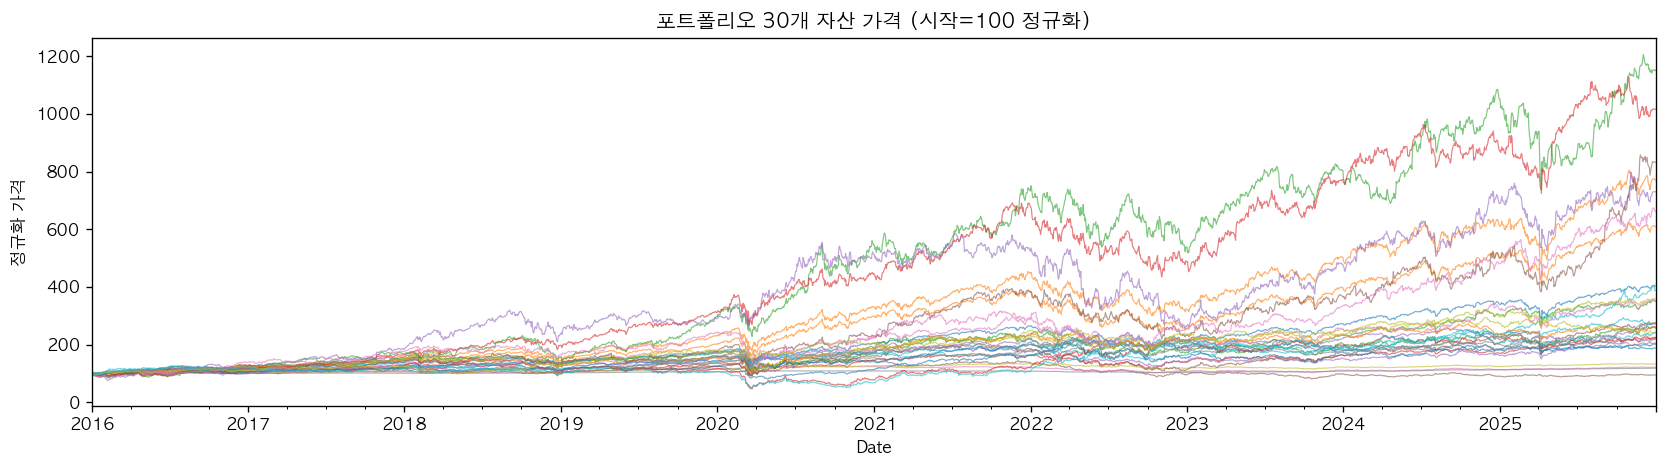

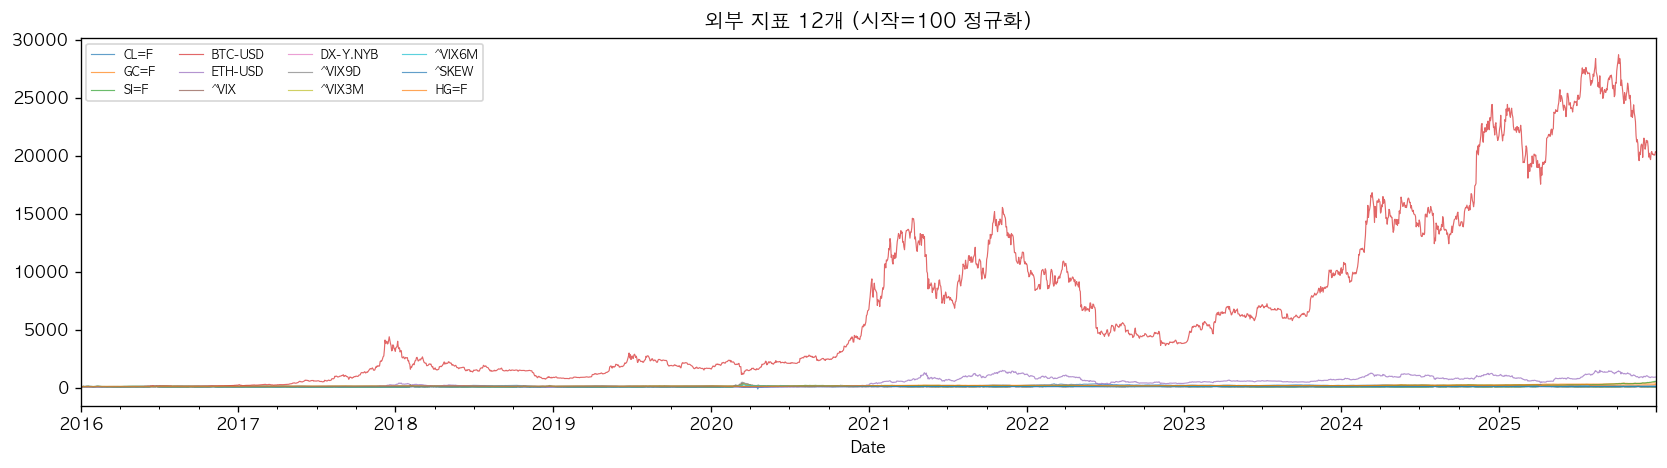

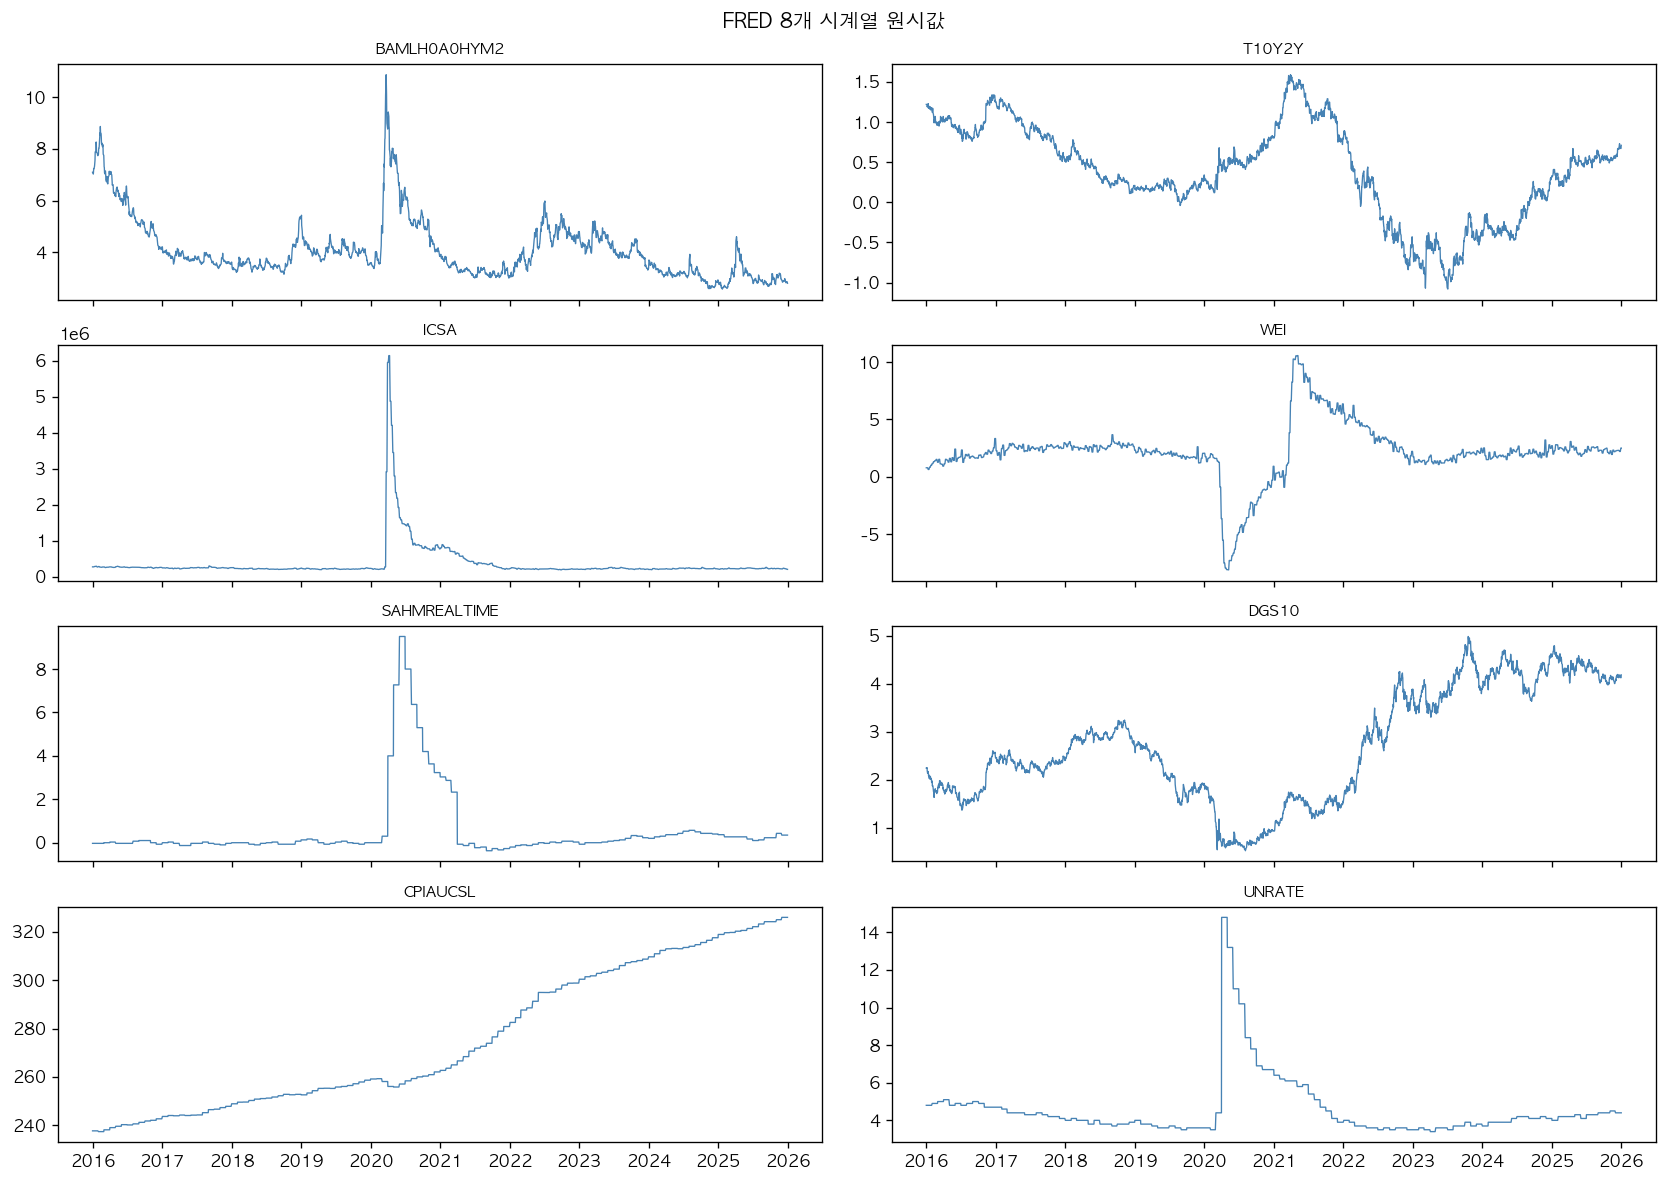

In [6]:
# ── 원본 시계열 시각화 ────────────────────────────────────────────

# (1) 포트폴리오 30개 — 시작=100 정규화
fig, ax = plt.subplots(figsize=(14, 4))
(port / port.iloc[0] * 100).plot(ax=ax, lw=0.7, legend=False, alpha=0.6)
ax.set_title('포트폴리오 30개 자산 가격 (시작=100 정규화)', fontsize=12, fontweight='bold')
ax.set_ylabel('정규화 가격')
plt.tight_layout()
plt.show()

# (2) 외부 지표 12개 — 시작=100 정규화
fig, ax = plt.subplots(figsize=(14, 4))
(ext / ext.iloc[0] * 100).plot(ax=ax, lw=0.7, alpha=0.7)
ax.set_title('외부 지표 12개 (시작=100 정규화)', fontsize=12, fontweight='bold')
ax.legend(fontsize=7, ncol=4, loc='upper left')
plt.tight_layout()
plt.show()

# (3) FRED 8개 — 각각 스케일이 달라서 개별 subplot
fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)
for ax, col in zip(axes.flatten(), fred.columns):
    ax.plot(fred.index, fred[col], lw=0.8, color='steelblue')
    ax.set_title(col, fontsize=9, fontweight='bold')
plt.suptitle('FRED 8개 시계열 원시값', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 2. 정상성 확인
시계열 자료는 정규성이 아닌 정상성을 만족해야 함!
#### 정상성이란?
"시간이 지나도 통계적 성질이 유지되는 것" : 평균 일정 + 분산 일정 + 추세 없음 -> ARIMA 같은 모델이 이걸 가정함
* 주가: 가격(Price) 데이터이므로 로그 수익률로 변환하여 '비율'로 만듦. (로그 수익률도 차분 개념)
* VIX: 변동성(Volatility)이라는 '지수/비율' 데이터이므로 단순 차분을 통해 '변화량'만 추출함.

In [7]:
from statsmodels.tsa.stattools import adfuller

def adf_test(df, name):
    results = []
    for col in df.columns:
        series = df[col].dropna()
        adf_stat, p_val, *_ = adfuller(series, autolag='AIC')
        results.append({
            'variable':   col,
            'ADF_stat':   round(adf_stat, 4),
            'p_value':    round(p_val, 4),
            'stationary': '정상' if p_val < 0.05 else '비정상'
        })
    result_df = pd.DataFrame(results).sort_values('p_value', ascending=False)
    
    n_non = (result_df['stationary'] == '비정상').sum()
    print(f'\n{"=" * 50}')
    print(f'  {name}  |  비정상: {n_non}/{len(result_df)}개')
    print(f'{"=" * 50}')
    return result_df

adf_port = adf_test(port, '포트폴리오 (30개)')
display(adf_port)
adf_ext  = adf_test(ext,  '외부 지표 (12개)')
display(adf_ext)
adf_fred = adf_test(fred, 'FRED (8개)')
display(adf_fred)


  포트폴리오 (30개)  |  비정상: 30/30개


,variable,ADF_stat,p_value,stationary
9,GLD,4.3057,1.0000,비정상
25,GOOGL,2.2776,0.9989,비정상
26,JPM,1.7648,0.9983,비정상
7,SHY,1.3309,0.9968,비정상
11,XLK,1.0423,0.9947,비정상
0,SPY,0.9329,0.9935,비정상
1,QQQ,0.8874,0.9929,비정상
15,VOX,0.6841,0.9895,비정상
22,AAPL,0.3990,0.9815,비정상
18,XLI,0.3440,0.9793,비정상



  외부 지표 (12개)  |  비정상: 7/12개


,variable,ADF_stat,p_value,stationary
1,GC=F,4.8216,1.0000,비정상
2,SI=F,4.6715,1.0000,비정상
11,HG=F,-0.7627,0.8298,비정상
3,BTC-USD,-0.8674,0.7985,비정상
4,ETH-USD,-2.0051,0.2843,비정상
6,DX-Y.NYB,-2.1149,0.2385,비정상
0,CL=F,-2.6290,0.0871,비정상
9,^VIX6M,-3.0352,0.0317,정상
10,^SKEW,-3.5655,0.0065,정상
8,^VIX3M,-3.6249,0.0053,정상



  FRED (8개)  |  비정상: 3/8개


,variable,ADF_stat,p_value,stationary
6,CPIAUCSL,0.8406,0.9923,비정상
5,DGS10,-0.7530,0.8326,비정상
1,T10Y2Y,-1.6394,0.4626,비정상
7,UNRATE,-3.2414,0.0177,정상
3,WEI,-3.3510,0.0127,정상
4,SAHMREALTIME,-3.8216,0.0027,정상
0,BAMLH0A0HYM2,-3.8757,0.0022,정상
2,ICSA,-4.8389,0.0000,정상


In [8]:
# ── KPSS 검정 ────────────────────────────────────────────────
# ADF와 귀무가설이 반대:
#   ADF  H₀: 단위근 있음(비정상)  → p < 0.05 이면 정상
#   KPSS H₀: 정상              → p < 0.05 이면 비정상
from statsmodels.tsa.stattools import kpss

def kpss_test(df, name):
    results = []
    for col in df.columns:
        series = df[col].dropna()
        kpss_stat, p_val, *_ = kpss(series, regression='c', nlags='auto')
        results.append({
            'variable':   col,
            'KPSS_stat':  round(kpss_stat, 4),
            'p_value':    round(p_val, 4),
            'stationary': '정상' if p_val >= 0.05 else '비정상'
        })
    result_df = pd.DataFrame(results).sort_values('p_value')

    n_non = (result_df['stationary'] == '비정상').sum()
    print(f'\n{"=" * 50}')
    print(f'  {name}  |  비정상: {n_non}/{len(result_df)}개')
    print(f'{"=" * 50}')
    return result_df

kpss_port = kpss_test(port, '포트폴리오 (30개)')
display(kpss_port)
kpss_ext  = kpss_test(ext,  '외부 지표 (12개)')
display(kpss_ext)
kpss_fred = kpss_test(fred, 'FRED (8개)')
display(kpss_fred)



  포트폴리오 (30개)  |  비정상: 30/30개


,variable,KPSS_stat,p_value,stationary
0,SPY,7.7868,0.01,비정상
27,JNJ,7.4800,0.01,비정상
26,JPM,6.4880,0.01,비정상
25,GOOGL,6.9919,0.01,비정상
24,AMZN,6.6658,0.01,비정상
23,MSFT,8.0653,0.01,비정상
22,AAPL,8.1838,0.01,비정상
21,XLB,7.8969,0.01,비정상
20,XLRE,7.0139,0.01,비정상
19,XLU,7.6198,0.01,비정상



  외부 지표 (12개)  |  비정상: 12/12개


,variable,KPSS_stat,p_value,stationary
0,CL=F,3.4235,0.0100,비정상
1,GC=F,6.2304,0.0100,비정상
2,SI=F,5.3014,0.0100,비정상
3,BTC-USD,6.0714,0.0100,비정상
4,ETH-USD,5.7153,0.0100,비정상
5,^VIX,0.9490,0.0100,비정상
6,DX-Y.NYB,3.1978,0.0100,비정상
8,^VIX3M,1.2137,0.0100,비정상
9,^VIX6M,1.5044,0.0100,비정상
10,^SKEW,2.2182,0.0100,비정상



  FRED (8개)  |  비정상: 6/8개


,variable,KPSS_stat,p_value,stationary
0,BAMLH0A0HYM2,1.7051,0.0100,비정상
1,T10Y2Y,2.8460,0.0100,비정상
5,DGS10,4.3226,0.0100,비정상
6,CPIAUCSL,8.3040,0.0100,비정상
7,UNRATE,0.5531,0.0297,비정상
4,SAHMREALTIME,0.4714,0.0481,비정상
2,ICSA,0.4263,0.0658,정상
3,WEI,0.2896,0.1000,정상


In [9]:
# ── ADF + KPSS 종합 판정 ─────────────────────────────────────
def combined_judgment(adf_df, kpss_df, name):
    merged = adf_df[['variable','stationary']].merge(
        kpss_df[['variable','stationary']], on='variable', suffixes=('_ADF','_KPSS')
    )

    def judge(row):
        a, k = row['stationary_ADF'], row['stationary_KPSS']
        if   a == '정상'   and k == '정상':   return '✅ 정상 (일치)'
        elif a == '비정상' and k == '비정상': return '❌ 비정상 (일치)'
        elif a == '정상'   and k == '비정상': return '⚠️ 추세정상 (불일치)'
        else:                                  return '❓ 불확실 (불일치)'

    merged['판정'] = merged.apply(judge, axis=1)

    print(f'\n{"=" * 55}')
    print(f'  {name} — ADF + KPSS 종합 판정')
    print(f'{"=" * 55}')
    return merged[['variable','stationary_ADF','stationary_KPSS','판정']]

comb_port = combined_judgment(adf_port, kpss_port, '포트폴리오')
display(comb_port)
comb_ext  = combined_judgment(adf_ext,  kpss_ext,  '외부 지표')
display(comb_ext)
comb_fred = combined_judgment(adf_fred, kpss_fred, 'FRED')
display(comb_fred)



  포트폴리오 — ADF + KPSS 종합 판정


,variable,stationary_ADF,stationary_KPSS,판정
0,GLD,비정상,비정상,❌ 비정상 (일치)
1,GOOGL,비정상,비정상,❌ 비정상 (일치)
2,JPM,비정상,비정상,❌ 비정상 (일치)
3,SHY,비정상,비정상,❌ 비정상 (일치)
4,XLK,비정상,비정상,❌ 비정상 (일치)
5,SPY,비정상,비정상,❌ 비정상 (일치)
6,QQQ,비정상,비정상,❌ 비정상 (일치)
7,VOX,비정상,비정상,❌ 비정상 (일치)
8,AAPL,비정상,비정상,❌ 비정상 (일치)
9,XLI,비정상,비정상,❌ 비정상 (일치)



  외부 지표 — ADF + KPSS 종합 판정


,variable,stationary_ADF,stationary_KPSS,판정
0,GC=F,비정상,비정상,❌ 비정상 (일치)
1,SI=F,비정상,비정상,❌ 비정상 (일치)
2,HG=F,비정상,비정상,❌ 비정상 (일치)
3,BTC-USD,비정상,비정상,❌ 비정상 (일치)
4,ETH-USD,비정상,비정상,❌ 비정상 (일치)
5,DX-Y.NYB,비정상,비정상,❌ 비정상 (일치)
6,CL=F,비정상,비정상,❌ 비정상 (일치)
7,^VIX6M,정상,비정상,⚠️ 추세정상 (불일치)
8,^SKEW,정상,비정상,⚠️ 추세정상 (불일치)
9,^VIX3M,정상,비정상,⚠️ 추세정상 (불일치)



  FRED — ADF + KPSS 종합 판정


,variable,stationary_ADF,stationary_KPSS,판정
0,CPIAUCSL,비정상,비정상,❌ 비정상 (일치)
1,DGS10,비정상,비정상,❌ 비정상 (일치)
2,T10Y2Y,비정상,비정상,❌ 비정상 (일치)
3,UNRATE,정상,비정상,⚠️ 추세정상 (불일치)
4,WEI,정상,정상,✅ 정상 (일치)
5,SAHMREALTIME,정상,비정상,⚠️ 추세정상 (불일치)
6,BAMLH0A0HYM2,정상,비정상,⚠️ 추세정상 (불일치)
7,ICSA,정상,정상,✅ 정상 (일치)


#### KPSS 검정 해석 기준

ADF와 KPSS는 귀무가설이 정반대이므로, **두 검정을 함께 보면 더 신뢰도 높은 판단**이 가능합니다.

| ADF 결과 | KPSS 결과 | 종합 판정 | 조치 |
|----------|-----------|-----------|------|
| 정상 (p<0.05) | 정상 (p≥0.05) | ✅ **정상 (일치)** | 수준값 그대로 사용 |
| 비정상 (p≥0.05) | 비정상 (p<0.05) | ❌ **비정상 (일치)** | 차분 또는 로그수익률 변환 |
| 정상 (p<0.05) | 비정상 (p<0.05) | ⚠️ **추세정상 (불일치)** | 추세 제거 후 재검정 |
| 비정상 (p≥0.05) | 정상 (p≥0.05) | ❓ **불확실 (불일치)** | 시각적 확인 + 도메인 판단 |

> KPSS p-value는 statsmodels 기준 **0.01 / 0.05 / 0.10 / 0.10 이상** 경계값으로 보고됩니다.

#### 정상성 검정 결과에 따른 변환 기준

> **목적**: 고객 맞춤 자산배분 펀드 추천을 위한 리스크 관리 모델  
> 모델에 투입하는 모든 변수는 **정상(stationary)** 이어야 함

---

##### ❌ 비정상 (ADF·KPSS 일치) → 변환 필요

| 변수 유형 | 해당 변수 | 변환 방법 | 이유 |
|-----------|-----------|-----------|------|
| 자산 가격 | SPY, QQQ 등 30개, CL=F, GC=F, BTC 등 | 로그 수익률 `ln(Pt/Pt-1)` | 우상향 트렌드 제거, 수익률이 투자 관점에서 의미 있음 |
| 금리·실업률·물가 | DGS10, UNRATE, CPIAUCSL | 단순 차분 `diff()` | 수준값보다 변화 방향이 리스크 신호 |

---

##### ✅ 정상 (ADF·KPSS 일치) → 수준값 그대로 사용

| 변수 유형 | 해당 변수 | 이유 |
|-----------|-----------|------|
| 스프레드 | T10Y2Y, BAMLH0A0HYM2 | 스프레드 수준 자체가 신용·경기 리스크 지표 |
| 변동성 지수 | ^VIX, ^VIX9D, ^VIX3M, ^VIX6M | 평균회귀 특성으로 수준값이 정상, 현재 시장 리스크 직접 표현 |
| 경기 지표 | WEI, SAHMREALTIME | 리스크 신호용으로 설계된 지수 |

---

##### ⚠️ 불일치 → 추가 판단 필요

| 케이스 | 의미 | 조치 |
|--------|------|------|
| ADF 정상 + KPSS 비정상 | 추세정상(trend-stationary) 가능성 | 추세 제거(`detrend`) 후 재검정 |
| ADF 비정상 + KPSS 정상 | 단위근 판단 불확실 | 시각적 확인 + 도메인 지식 우선 적용 |

#### 불일치 케이스 상세 설명

두 검정의 귀무가설이 반대이기 때문에, 불일치가 발생하면 단순히 변환을 적용하기 전에 **원인을 먼저 파악**해야 합니다.

```
ADF  H₀: 단위근 있음 (비정상)  → p < 0.05 이면 "정상"
KPSS H₀: 정상               → p < 0.05 이면 "비정상"
```

---

##### 케이스 1. ADF 정상 + KPSS 비정상 → 추세정상 (Trend-Stationary)

시계열이 **결정론적 추세(deterministic trend)** 를 가질 때 발생합니다.

```
실제 시계열 = 추세 + 정상 성분

예) 금리 = 완만한 하향 추세 + 주변을 오르내리는 정상 성분
```

- ADF는 추세가 있어도 "단위근은 아니야"라고 판정할 수 있음
- KPSS는 추세 자체를 비정상으로 잡아냄

**조치**: 선형 추세를 제거하고 잔차를 재검정

```python
from scipy.signal import detrend
series_detrended = detrend(series)  # 선형 추세 제거 후 재검정
```

---

##### 추세의 종류: 결정론적 vs 확률적

두 케이스를 이해하려면 추세의 종류를 구분해야 합니다.

| | 확률적 추세 (Stochastic Trend) | 결정론적 추세 (Deterministic Trend) |
|--|-------------------------------|--------------------------------------|
| **정의** | 충격이 누적되어 경로가 무작위로 표류 | 시간에 따라 고정된 방향으로 일정하게 움직임 |
| **수식** | $y_t = y_{t-1} + \epsilon_t$ (랜덤워크) | $y_t = \alpha + \beta t + \epsilon_t$ (선형 시간 추세) |
| **제거 방법** | 차분 (differencing) | 추세 제거 (detrending) |
| **어떤 검정이 잡나** | ADF | KPSS가 추가로 잡음 |

> 케이스 1(ADF 정상 + KPSS 비정상)은 **결정론적 추세**가 있는 경우,  
> 케이스 2(ADF 비정상 + KPSS 정상)는 **확률적 추세** 판단이 불확실한 경우입니다.

---

##### 케이스 2. ADF 비정상 + KPSS 정상 → 불확실 (Near Unit Root)

시계열이 **단위근에 가깝지만 엄밀히는 아닌** 경계 상태일 때 나옵니다.

```
예) VIX — 이론적으론 평균회귀하지만
    표본 기간이 짧으면 ADF가 단위근으로 잘못 판정하기도 함
```

- ADF는 표본이 짧을수록 비정상 판정에 보수적 (검정력 약함)
- KPSS는 반대로 짧은 표본에서 정상 쪽으로 관대한 경향

**조치 순서**:
1. 시각적으로 시계열 확인 (트렌드가 보이는가?)
2. 도메인 지식 우선 (VIX·스프레드는 이론적으로 평균회귀)
3. 표본 기간을 나눠 각 구간별 재검정

---

##### 불일치가 자주 나오는 변수 유형

| 변수 유형 | 불일치 이유 |
|-----------|-------------|
| VIX 계열 | 평균회귀하지만 위기 때 급등 → 표본에 따라 판정이 흔들림 |
| 금리 (DGS10 등) | 장기 하향 추세 존재 → 추세정상 케이스 자주 발생 |
| 실업률 (UNRATE) | 경기 사이클 따라 움직여 구조 변화 가능성 |
| 원자재 (GC=F, CL=F) | 인플레이션 추세 + 공급 충격 혼재 |

---

##### 한 줄 요약

| 케이스 | 실제 의미 | 핵심 조치 |
|--------|-----------|-----------|
| ADF 정상 + KPSS 비정상 | 추세는 있지만 단위근은 아님 | 추세 제거 후 재검정 |
| ADF 비정상 + KPSS 정상 | 단위근 판단 불확실, 경계 상태 | 도메인 지식 + 시각 확인 우선 |

> 두 검정이 모두 일치할 때만 결과를 확신할 수 있고,  
> **불일치는 "기계적으로 변환하지 말고 한 번 더 들여다보라"는 신호**입니다.

In [18]:
# ── 비정상 변수 변환 후 재검정 (ADF + KPSS) ───────────────────
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.signal import detrend as scipy_detrend

VIX_COLS = [c for c in ext.columns if 'VIX' in c.upper()]
all_comb  = pd.concat([comb_port, comb_ext, comb_fred])

# ── 케이스별 변수 분류 ────────────────────────────────────────
# ❌ ADF·KPSS 일치 비정상 → 차분/로그수익률
nonstat_port = comb_port[comb_port['판정'] == '❌ 비정상 (일치)']['variable'].tolist()
nonstat_ext  = comb_ext [comb_ext ['판정'] == '❌ 비정상 (일치)']['variable'].tolist()
nonstat_fred = comb_fred[comb_fred['판정'] == '❌ 비정상 (일치)']['variable'].tolist()

# ⚠️ 추세정상 (ADF 정상 + KPSS 비정상) → 추세 제거
trend_vars = all_comb[all_comb['판정'] == '⚠️ 추세정상 (불일치)']['variable'].tolist()

print(f'❌ 비정상 확정 — 포트폴리오: {len(nonstat_port)}개, 외부지표: {len(nonstat_ext)}개, FRED: {len(nonstat_fred)}개')
print(f'⚠️ 추세정상   — {len(trend_vars)}개: {trend_vars}')

# ── ADF + KPSS 동시 재검정 함수 ──────────────────────────────
def retest(df, name, trans_map=None):
    results = []
    for col in df.columns:
        s = df[col].dropna()
        adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
        kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
        adf_judge  = '정상'   if adf_p  < 0.05  else '비정상'
        kpss_judge = '정상'   if kpss_p >= 0.05 else '비정상'
        if   adf_judge == '정상'   and kpss_judge == '정상':   final = '✅ 정상'
        elif adf_judge == '비정상' and kpss_judge == '비정상': final = '❌ 비정상'
        elif adf_judge == '정상'   and kpss_judge == '비정상': final = '⚠️ 추세정상'
        else:                                                    final = '❓ 불확실'
        row = {
            'variable': col,
            'ADF_p':    round(adf_p,  4), 'ADF_판정':  adf_judge,
            'KPSS_p':   round(kpss_p, 4), 'KPSS_판정': kpss_judge,
            '최종':     final,
        }
        if trans_map:
            row['변환방법'] = trans_map.get(col, '-')
        results.append(row)
    result_df = pd.DataFrame(results).sort_values('최종')
    n_ok  = result_df['최종'].str.contains('정상$').sum()
    n_bad = (result_df['최종'] == '❌ 비정상').sum()
    print(f'\n{"=" * 55}')
    print(f'  {name}  |  정상: {n_ok}개  비정상 잔존: {n_bad}개')
    print(f'{"=" * 55}')
    cols = (['변환방법'] + [c for c in result_df.columns if c != '변환방법']) if trans_map else list(result_df.columns)
    return result_df[cols]

# ── 1. ❌ 비정상 확정 → 차분/로그수익률 변환 후 재검정 ───────────
port_trans = np.log(port[nonstat_port] / port[nonstat_port].shift(1)).dropna() if nonstat_port else pd.DataFrame()

nonstat_vix    = [c for c in nonstat_ext if c in VIX_COLS]
nonstat_ext_nv = [c for c in nonstat_ext if c not in VIX_COLS]
ext_trans = pd.concat([
    np.log(ext[nonstat_ext_nv] / ext[nonstat_ext_nv].shift(1)) if nonstat_ext_nv else pd.DataFrame(),
    ext[nonstat_vix].diff()                                     if nonstat_vix    else pd.DataFrame()
], axis=1).dropna() if nonstat_ext else pd.DataFrame()

fred_trans = fred[nonstat_fred].diff().dropna() if nonstat_fred else pd.DataFrame()

if not port_trans.empty:
    display(retest(port_trans, '포트폴리오 → 로그수익률', {c: '로그수익률' for c in port_trans.columns}))
if not ext_trans.empty:
    tmap = {c: '로그수익률' for c in nonstat_ext_nv}
    tmap.update({c: '차분' for c in nonstat_vix})
    display(retest(ext_trans, '외부지표 → 로그수익률/차분', tmap))
if not fred_trans.empty:
    display(retest(fred_trans, 'FRED → 차분', {c: '차분' for c in fred_trans.columns}))

# ── 2. ⚠️ 추세정상 → 선형 추세 제거 후 재검정 ─────────────────
if trend_vars:
    all_raw = pd.concat([port, ext, fred], axis=1)
    detrended_dict = {}
    for col in trend_vars:
        s = all_raw[col].dropna()
        detrended_dict[col] = pd.Series(scipy_detrend(s.values), index=s.index)
    trend_trans = pd.DataFrame(detrended_dict)
    display(retest(trend_trans, '추세정상 변수 → 선형 추세 제거', {c: 'detrend' for c in trend_vars}))


❌ 비정상 확정 — 포트폴리오: 30개, 외부지표: 7개, FRED: 3개
⚠️ 추세정상   — 8개: ['^VIX6M', '^SKEW', '^VIX3M', '^VIX', '^VIX9D', 'UNRATE', 'SAHMREALTIME', 'BAMLH0A0HYM2']

  포트폴리오 → 로그수익률  |  정상: 30개  비정상 잔존: 0개


,변환방법,variable,ADF_p,ADF_판정,KPSS_p,KPSS_판정,최종
3,로그수익률,SHY,0.0,정상,0.0248,비정상,⚠️ 추세정상
0,로그수익률,GLD,0.0,정상,0.0890,정상,✅ 정상
1,로그수익률,GOOGL,0.0,정상,0.1000,정상,✅ 정상
2,로그수익률,JPM,0.0,정상,0.1000,정상,✅ 정상
4,로그수익률,XLK,0.0,정상,0.1000,정상,✅ 정상
5,로그수익률,SPY,0.0,정상,0.1000,정상,✅ 정상
6,로그수익률,QQQ,0.0,정상,0.1000,정상,✅ 정상
7,로그수익률,VOX,0.0,정상,0.1000,정상,✅ 정상
8,로그수익률,AAPL,0.0,정상,0.1000,정상,✅ 정상
9,로그수익률,XLI,0.0,정상,0.1000,정상,✅ 정상



  외부지표 → 로그수익률/차분  |  정상: 7개  비정상 잔존: 0개


,변환방법,variable,ADF_p,ADF_판정,KPSS_p,KPSS_판정,최종
0,로그수익률,GC=F,0.0,정상,0.0942,정상,✅ 정상
1,로그수익률,SI=F,0.0,정상,0.1000,정상,✅ 정상
2,로그수익률,HG=F,0.0,정상,0.1000,정상,✅ 정상
3,로그수익률,BTC-USD,0.0,정상,0.1000,정상,✅ 정상
4,로그수익률,ETH-USD,0.0,정상,0.1000,정상,✅ 정상
5,로그수익률,DX-Y.NYB,0.0,정상,0.1000,정상,✅ 정상
6,로그수익률,CL=F,0.0,정상,0.1000,정상,✅ 정상



  FRED → 차분  |  정상: 3개  비정상 잔존: 0개


,변환방법,variable,ADF_p,ADF_판정,KPSS_p,KPSS_판정,최종
0,차분,CPIAUCSL,0.0,정상,0.01,비정상,⚠️ 추세정상
1,차분,DGS10,0.0,정상,0.10,정상,✅ 정상
2,차분,T10Y2Y,0.0,정상,0.10,정상,✅ 정상



  추세정상 변수 → 선형 추세 제거  |  정상: 8개  비정상 잔존: 0개


,변환방법,variable,ADF_p,ADF_판정,KPSS_p,KPSS_판정,최종
0,detrend,^VIX6M,0.0195,정상,0.0100,비정상,⚠️ 추세정상
2,detrend,^VIX3M,0.0033,정상,0.0100,비정상,⚠️ 추세정상
3,detrend,^VIX,0.0000,정상,0.0236,비정상,⚠️ 추세정상
6,detrend,SAHMREALTIME,0.0027,정상,0.0482,비정상,⚠️ 추세정상
1,detrend,^SKEW,0.0006,정상,0.1000,정상,✅ 정상
4,detrend,^VIX9D,0.0000,정상,0.0579,정상,✅ 정상
5,detrend,UNRATE,0.0165,정상,0.0745,정상,✅ 정상
7,detrend,BAMLH0A0HYM2,0.0018,정상,0.1000,정상,✅ 정상


### 3. 상관관계 분석

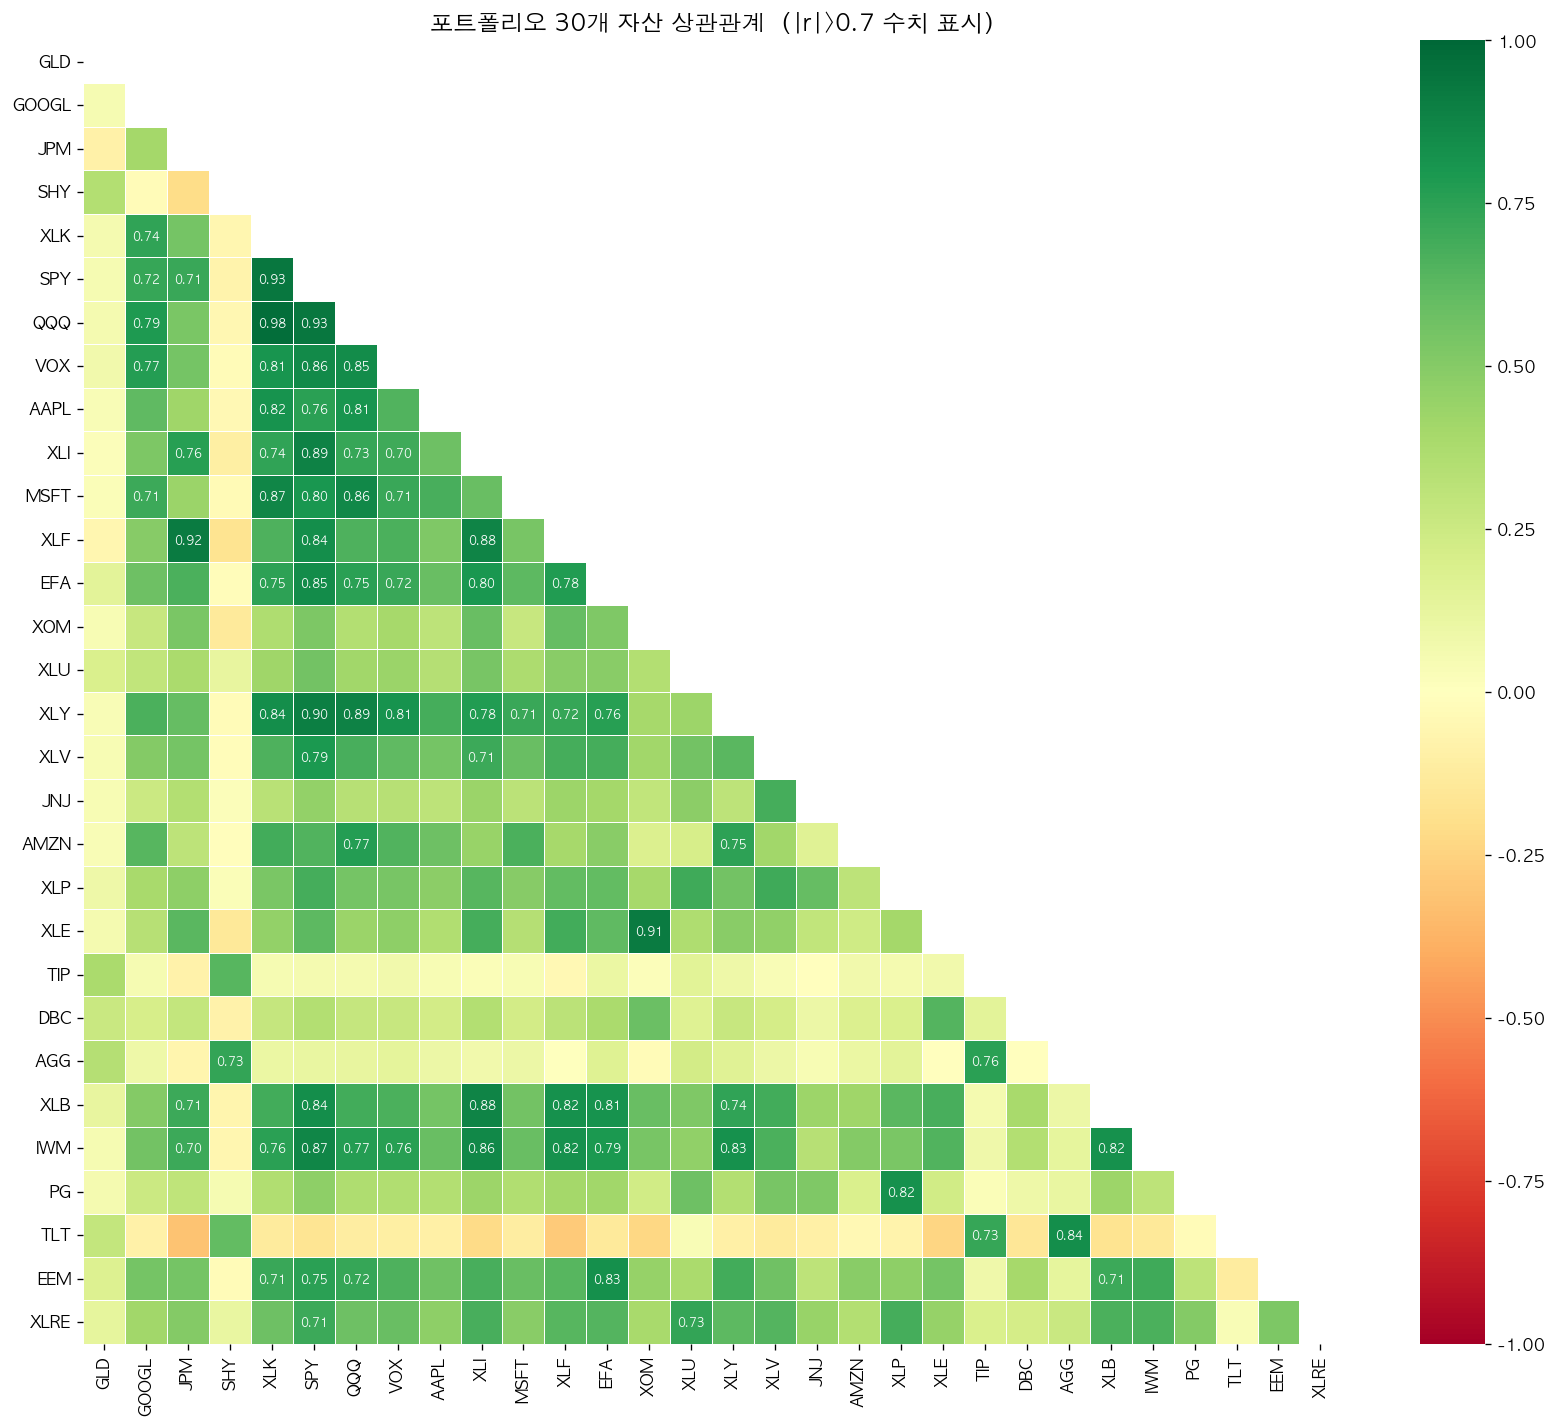

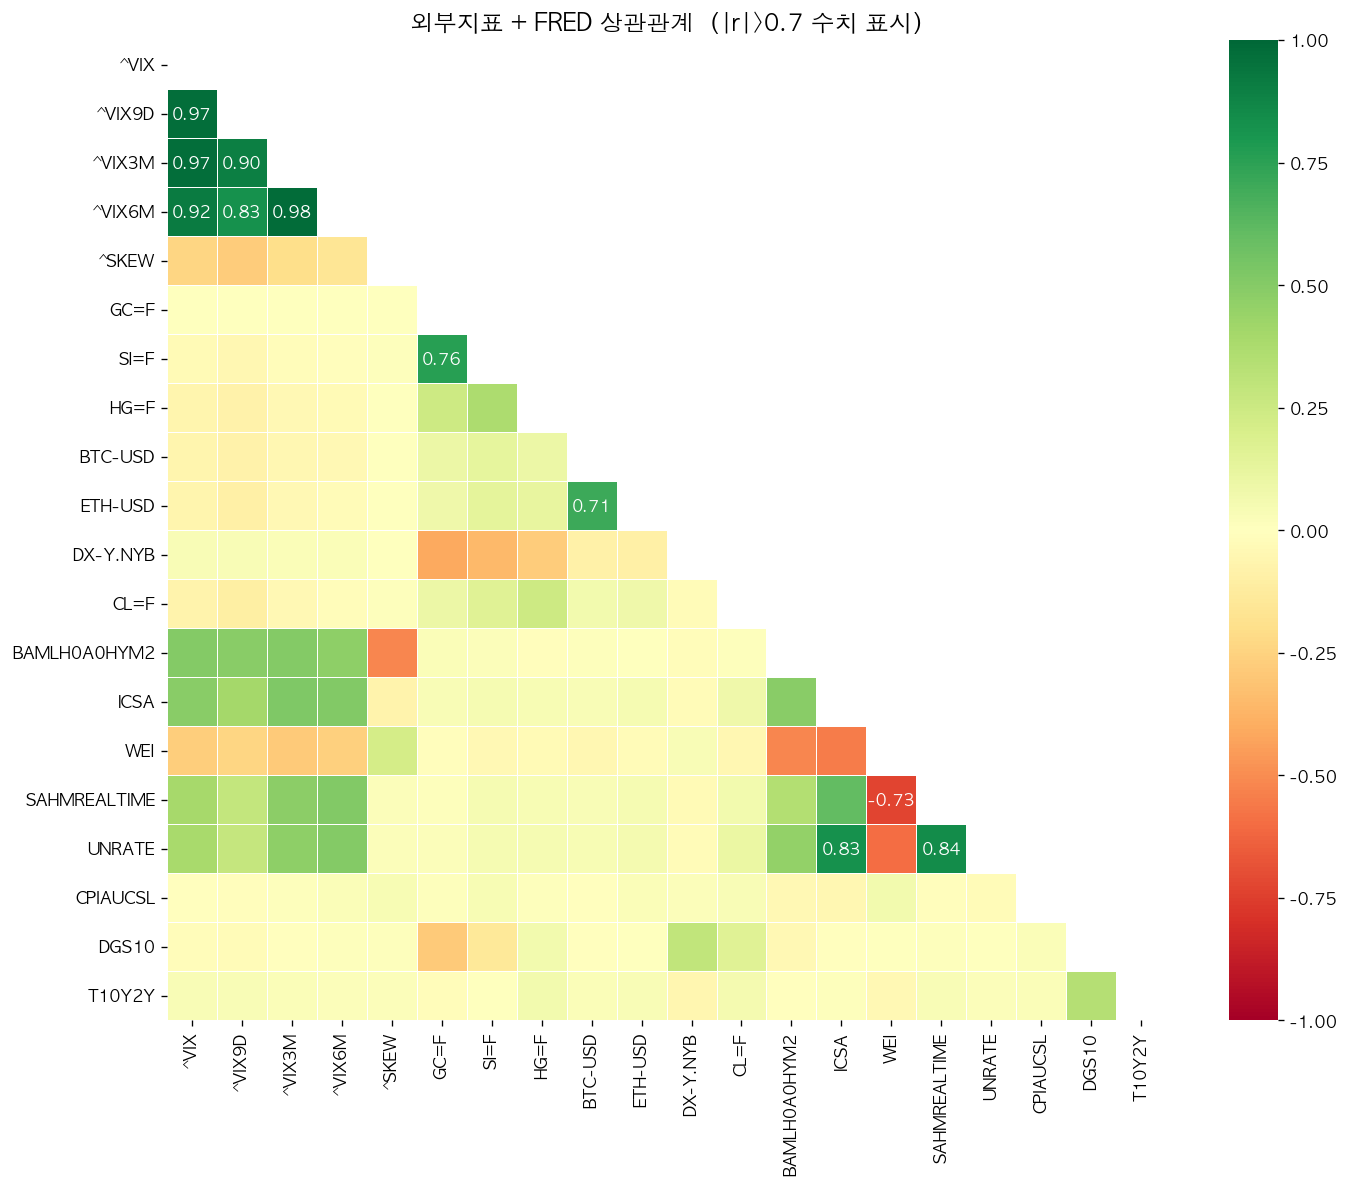


  포트폴리오 (30개)  |  고상관 쌍: 74개


,변수1,변수2,상관계수
12,XLK,QQQ,0.9750
21,SPY,QQQ,0.9333
11,XLK,SPY,0.9300
7,JPM,XLF,0.9162
63,XOM,XLE,0.9145
28,SPY,XLY,0.8992
24,SPY,XLI,0.8881
39,QQQ,XLY,0.8863
52,XLI,XLB,0.8807
48,XLI,XLF,0.8753



  외부지표 + FRED  |  고상관 쌍: 11개


,변수1,변수2,상관계수
5,^VIX3M,^VIX6M,0.9828
1,^VIX,^VIX3M,0.9716
0,^VIX,^VIX9D,0.9712
2,^VIX,^VIX6M,0.9196
3,^VIX9D,^VIX3M,0.9050
10,SAHMREALTIME,UNRATE,0.8444
4,^VIX9D,^VIX6M,0.8281
8,ICSA,UNRATE,0.8251
6,GC=F,SI=F,0.7612
9,WEI,SAHMREALTIME,-0.7307


In [11]:
# ── 상관관계 분석 ─────────────────────────────────────────────

# 1. 정상 변수 통합 (원본 정상 + 변환된 비정상)
stat_port = [c for c in port.columns if c not in nonstat_port]
stat_ext  = [c for c in ext.columns  if c not in nonstat_ext]
stat_fred = [c for c in fred.columns if c not in nonstat_fred]

port_final = pd.concat([port[stat_port], port_trans], axis=1).dropna()
ext_final  = pd.concat([ext[stat_ext],   ext_trans],  axis=1).dropna()
fred_final = pd.concat([fred[stat_fred],  fred_trans], axis=1).dropna()

# 2. 포트폴리오 자산 간 상관관계 (30×30)
corr_port = port_final.corr()
annot_port = corr_port.map(lambda x: f"{x:.2f}" if abs(x) > 0.7 else "")
mask = np.triu(np.ones_like(corr_port, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_port, mask=mask, annot=annot_port, fmt="", cmap="RdYlGn",
            vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.3, annot_kws={"size": 7})
ax.set_title("포트폴리오 30개 자산 상관관계  (|r|>0.7 수치 표시)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 3. 외부지표 + FRED 상관관계
ext_fred = pd.concat([ext_final, fred_final], axis=1).dropna()
corr_ef  = ext_fred.corr()
annot_ef = corr_ef.map(lambda x: f"{x:.2f}" if abs(x) > 0.7 else "")
mask2 = np.triu(np.ones_like(corr_ef, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_ef, mask=mask2, annot=annot_ef, fmt="", cmap="RdYlGn",
            vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.5)
ax.set_title("외부지표 + FRED 상관관계  (|r|>0.7 수치 표시)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 4. 고상관 변수 쌍 (|r| > 0.7)
def high_corr_pairs(corr_matrix, label):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > 0.7:
                pairs.append({"변수1": cols[i], "변수2": cols[j], "상관계수": round(r, 4)})
    print(f"\n{'='*50}")
    print(f"  {label}  |  고상관 쌍: {len(pairs)}개")
    print(f"{'='*50}")
    if pairs:
        display(pd.DataFrame(pairs).sort_values("상관계수", key=lambda x: x.abs(), ascending=False))
    else:
        print("없음")

high_corr_pairs(corr_port, "포트폴리오 (30개)")
high_corr_pairs(corr_ef,   "외부지표 + FRED")


### 4. VIF (다중공선성 검정)

- **VIF > 10** : 제거 권고 — 다른 변수로 거의 완벽하게 설명됨
- **5 < VIF ≤ 10** : 주의 — 상황에 따라 검토
- **VIF ≤ 5** : 양호

> 상관관계는 두 변수 간 선형 관계만 보지만, VIF는 **한 변수가 나머지 모든 변수로 얼마나 설명되는지** 측정 → 다중공선성 진단에 더 정확

In [12]:
# ── VIF (다중공선성 검정) ─────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(df, name):
    df_clean = df.dropna()
    vif_data = pd.DataFrame({
        'variable': df_clean.columns,
        'VIF': [variance_inflation_factor(df_clean.values, i)
                for i in range(df_clean.shape[1])]
    })
    vif_data['VIF'] = vif_data['VIF'].round(2)
    vif_data['판정'] = vif_data['VIF'].apply(
        lambda x: '제거 권고' if x > 10 else ('주의' if x > 5 else '양호'))
    vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

    n_remove = (vif_data['판정'] == '제거 권고').sum()
    print(f'\n{"=" * 50}')
    print(f'  {name}  |  VIF>10 (제거권고): {n_remove}개')
    print(f'{"=" * 50}')
    display(vif_data)
    return vif_data

# 예측변수 VIF (외부지표 + FRED만)
vif_ext  = calc_vif(ext_final,  '외부지표')
vif_fred = calc_vif(fred_final, 'FRED')



  외부지표  |  VIF>10 (제거권고): 5개


,variable,VIF,판정
0,^VIX3M,2557.22,제거 권고
1,^VIX6M,1312.82,제거 권고
2,^VIX,928.97,제거 권고
3,^VIX9D,171.07,제거 권고
4,^SKEW,23.37,제거 권고
5,SI=F,2.67,양호
6,GC=F,2.59,양호
7,ETH-USD,2.04,양호
8,BTC-USD,2.01,양호
9,HG=F,1.27,양호



  FRED  |  VIF>10 (제거권고): 2개


,variable,VIF,판정
0,UNRATE,40.12,제거 권고
1,BAMLH0A0HYM2,16.53,제거 권고
2,SAHMREALTIME,6.24,주의
3,WEI,5.19,주의
4,ICSA,4.10,양호
5,DGS10,1.13,양호
6,T10Y2Y,1.13,양호
7,CPIAUCSL,1.03,양호


#### VIF 결과 해석

**① 외부지표 — VIX 계열 (VIF 1000~3000)**
- `^VIX`, `^VIX3M`, `^VIX6M`, `^VIX9D` 모두 시장 공포 수준을 측정 → 구조적으로 동일한 정보
- **→ `^VIX` 하나만 유지, 나머지 3개 제거**

**② 외부지표 — `^SKEW` (VIF 23)**
- VIX 계열과 연동되어 VIF가 올라간 영향
- VIX 계열 제거 후 재확인 필요

**③ FRED — `UNRATE` (VIF 40)**
- `SAHMREALTIME`은 실업률(`UNRATE`)로 계산되는 파생 지표 → 구조적으로 연동
- 경기침체 신호 목적에는 `SAHMREALTIME`이 더 직관적
- **→ `UNRATE` 제거, `SAHMREALTIME` 유지**

**④ FRED — `BAMLH0A0HYM2` (VIF 16)**
- 하이일드 스프레드는 경기·신용 환경을 반영 → `UNRATE`와 연동된 영향
- `UNRATE` 제거 후 VIF 재확인 필요

> **핵심**: 변수 자체의 문제가 아니라 동일 정보를 담은 변수를 중복 투입한 것이 원인 → 대표 변수 1개 선택으로 해결

### 5. Granger 인과 검정

**"외부지표/매크로 변수의 과거값이 포트폴리오 수익률 예측에 유의미한 정보를 추가하는가?"**

- 귀무가설(H₀): X는 Y를 Granger-cause 하지 않는다
- p < 0.05 → 귀무가설 기각 → X의 과거값이 Y 예측에 유의미
- 정상성이 확보된 변수에서만 신뢰 가능한 결과 → 앞서 변환한 변수 사용

유의한 Granger 인과 쌍 (p<0.05): 56개


,predictor,lag,p_value,significant
0,^VIX6M,3,0.0000,유의
1,ICSA,4,0.0000,유의
2,ICSA,3,0.0000,유의
3,ICSA,2,0.0000,유의
4,UNRATE,4,0.0000,유의
5,^VIX6M,5,0.0000,유의
6,^VIX6M,4,0.0000,유의
7,ICSA,5,0.0000,유의
8,^VIX3M,5,0.0000,유의
9,UNRATE,5,0.0000,유의


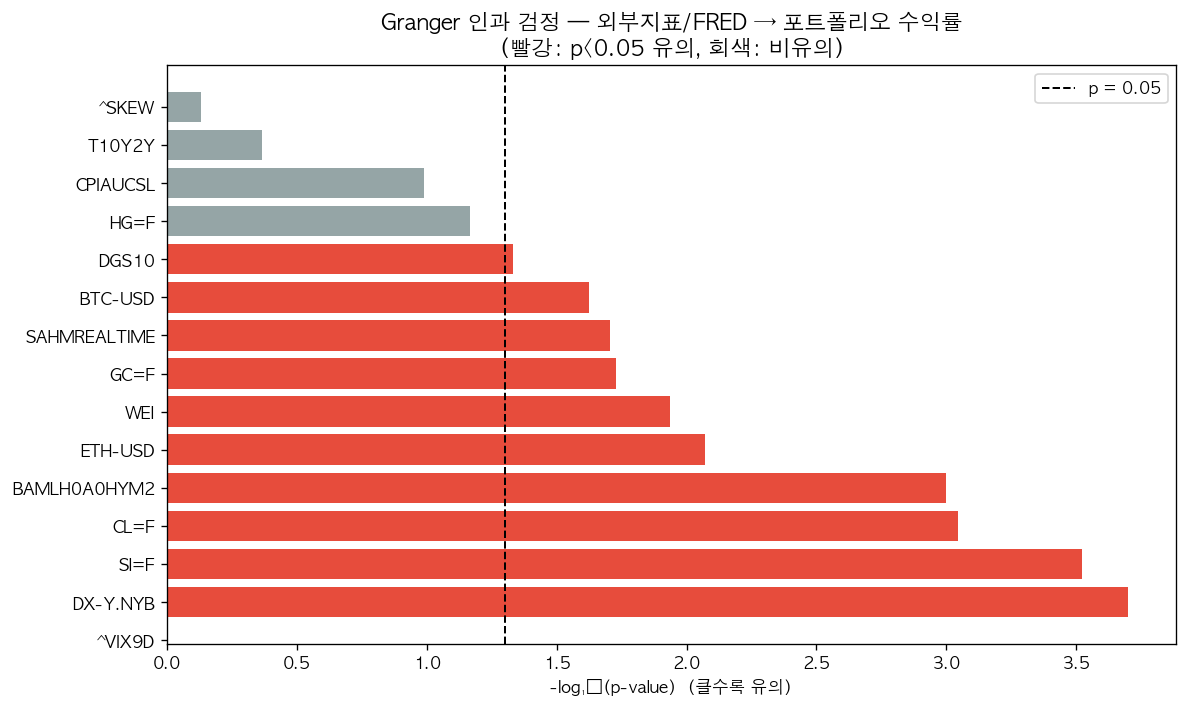

In [13]:
# ── Granger 인과 검정 ─────────────────────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests

# 등가중 포트폴리오 수익률 (타겟 Y)
port_ew = port_final.mean(axis=1)
port_ew.name = 'port_ew'

def run_granger(target, predictors, max_lag=5, alpha=0.05):
    results = []
    for col in predictors.columns:
        df_pair = pd.concat([target, predictors[col]], axis=1).dropna()
        df_pair.columns = ['target', 'predictor']
        try:
            test = grangercausalitytests(df_pair, maxlag=max_lag, verbose=False)
            for lag in range(1, max_lag + 1):
                p_val = test[lag][0]['ssr_ftest'][1]
                results.append({
                    'predictor': col,
                    'lag': lag,
                    'p_value': round(p_val, 4),
                    'significant': '유의' if p_val < alpha else '-'
                })
        except Exception:
            pass
    return pd.DataFrame(results)

# 외부지표 + FRED → 포트폴리오 수익률
predictors = pd.concat([ext_final, fred_final], axis=1)
granger_df = run_granger(port_ew, predictors, max_lag=5)

# 유의한 결과 출력
sig = granger_df[granger_df['significant'] == '유의'].sort_values('p_value')
print(f'유의한 Granger 인과 쌍 (p<0.05): {len(sig)}개')
display(sig.reset_index(drop=True))

# 변수별 최소 p-value (가장 유의한 시차 기준) 시각화
best = granger_df.groupby('predictor')['p_value'].min().reset_index()
best = best.sort_values('p_value').reset_index(drop=True)
best['sig'] = best['p_value'] < 0.05

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if s else '#95a5a6' for s in best['sig']]
ax.barh(best['predictor'], -np.log10(best['p_value']), color=colors)
ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1.2, label='p = 0.05')
ax.set_xlabel('-log₁₀(p-value)  (클수록 유의)')
ax.set_title('Granger 인과 검정 — 외부지표/FRED → 포트폴리오 수익률\n(빨강: p<0.05 유의, 회색: 비유의)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


#### Granger 검정 결과 해석

##### 검정 방법
- **타겟(Y)**: 포트폴리오 30개 자산의 등가중 수익률
- **예측변수(X)**: 외부지표 + FRED (정상화된 변수)
- **시차(lag)**: 1~5일, 각 변수의 최소 p-value 기준으로 판단
- **판단 기준**: p < 0.05 → X의 과거값이 Y 예측에 유의미한 정보 추가

---

##### 유의한 변수 (빨강, p < 0.05)

| 변수 | 의미 | 해석 |
|------|------|------|
| **DX-Y.NYB** | 달러 인덱스 | 달러 강세/약세가 시차를 두고 포트폴리오 전반에 영향 → 글로벌 자산에 공통 요인 |
| **SI=F** | 은 | 원자재 가격 변화가 포트폴리오 수익률 예측에 유의 |
| **CL=F** | 원유 | 에너지 가격이 경기·기업실적 경로로 수익률에 선행 |
| **BAMLH0A0HYM2** | 하이일드 스프레드 | 신용위험 확대 신호가 주가에 시차를 두고 반영 → 리스크 관리 핵심 지표 |
| **ETH-USD / BTC-USD** | 암호화폐 | 위험선호 지표로 작동, 최근 전통 자산과 연동 강화 |
| **WEI** | 주간경제지수 | 실시간 경기 모멘텀이 수익률에 선행 |
| **GC=F** | 금 | 안전자산 수요 변화가 포트폴리오에 선행 신호 |
| **SAHMREALTIME** | Sahm 경기침체 지표 | 경기침체 신호가 수익률 하락에 선행 |
| **DGS10** | 10년 국채금리 | 금리 변화가 할인율 경로로 주가에 시차 영향 |

##### 비유의한 변수 (회색, p ≥ 0.05)

| 변수 | 의미 | 해석 |
|------|------|------|
| **^VIX9D** | 단기 공포지수 | 현재값은 중요하지만 **과거값이 추가 정보를 제공하지 않음** → 동행지표에 가까움 |
| **^SKEW** | 꼬리 위험 지수 | 극단적 하락 위험 측정, 단기 수익률 예측력은 낮음 |
| **T10Y2Y** | 장단기 금리 스프레드 | 장기 경기 예측 지표, 단기 수익률 예측에는 시차가 너무 김 |
| **CPIAUCSL** | 소비자물가지수 | 월별 지표로 일별 수익률 예측에 한계 |
| **HG=F** | 구리 | 경기선행지표이나 이 포트폴리오 구성에서는 유의하지 않음 |

---

> **핵심**: 달러, 원자재(금·은·원유), 신용스프레드, 암호화폐가 포트폴리오 수익률에 선행하는 신호를 가짐  
> VIX는 **동행지표** 성격 → 현재 리스크 수준 파악에는 유용하지만 Granger 선행성은 약함

### 5-1. Granger 보완

**① 희소 데이터 확인**  
FRED 변수는 주간·월간 단위로 발표되지만 일별 데이터로 변환 시 forward-fill(이전 값 유지)됨  
→ 차분하면 발표일만 값이 존재하고 나머지는 전부 0  
→ Granger 검정이 '0의 패턴'에 반응해 잘못된 유의성을 보고할 수 있음

**② AIC 최적 Lag 선택**  
이전 방식(lag 1~5 중 최솟값)은 5번 테스트 후 가장 좋은 결과만 고르는 것 → 다중검정 문제  
→ VAR 모델의 AIC 기준으로 각 변수에 맞는 최적 lag를 먼저 찾고, 그 lag에서만 검정  
→ 결과의 신뢰도가 더 높아짐

=== FRED 변수 희소성 확인 (차분 후 0 비율) ===


,variable,0 비율,판정
5,CPIAUCSL,0.9548,희소 주의
7,T10Y2Y,0.1852,양호
3,SAHMREALTIME,0.1415,양호
6,DGS10,0.1258,양호
0,BAMLH0A0HYM2,0.0000,양호
1,ICSA,0.0000,양호
2,WEI,0.0000,양호
4,UNRATE,0.0000,양호



=== AIC 최적 Lag 기반 Granger 재검정 ===
희소 변수 제외: ['CPIAUCSL']


,predictor,best_lag(AIC),p_value,significant
0,^VIX,10,0.0000,유의
1,^VIX9D,9,0.0000,유의
2,^VIX3M,10,0.0000,유의
3,^VIX6M,10,0.0000,유의
4,UNRATE,10,0.0000,유의
5,SAHMREALTIME,10,0.0000,유의
6,ICSA,10,0.0000,유의
7,BAMLH0A0HYM2,10,0.0000,유의
8,CL=F,10,0.0006,유의
9,DX-Y.NYB,9,0.0027,유의


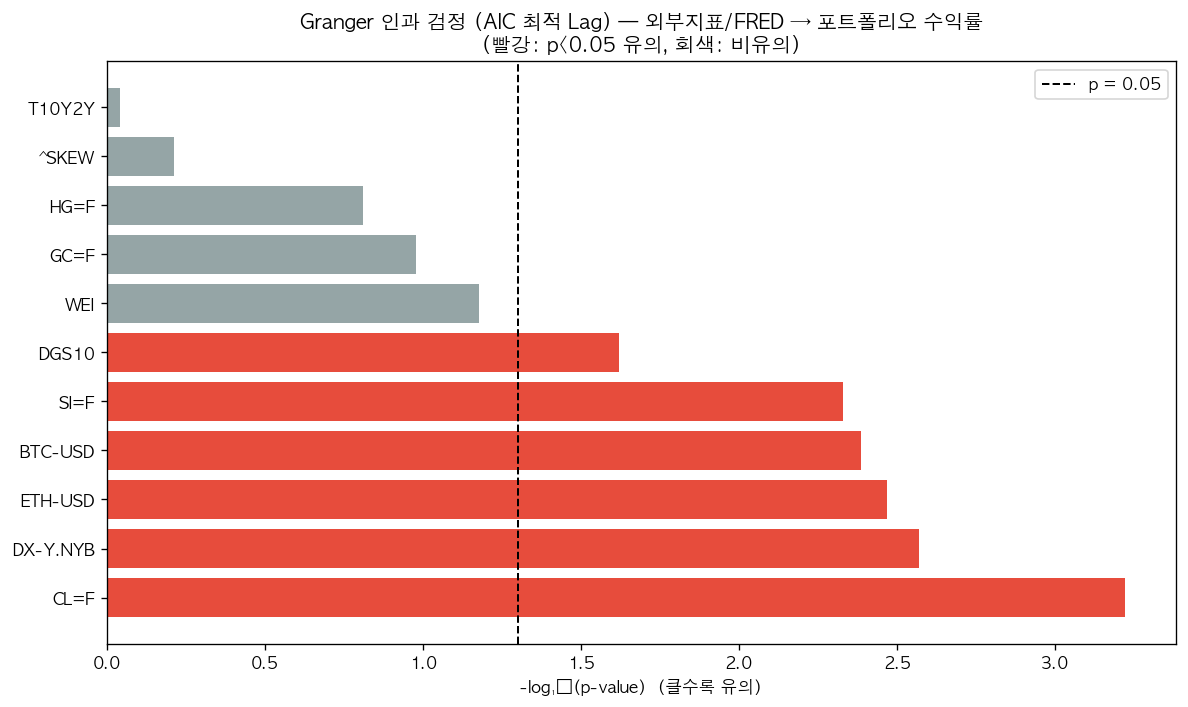

In [14]:
# ── Granger 보완 ──────────────────────────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR

# 1. 희소성 확인 (차분 후 0 비율)
print('=== FRED 변수 희소성 확인 (차분 후 0 비율) ===')
sparse_result = []
for col in fred_final.columns:
    zero_ratio = (fred_final[col] == 0).mean()
    sparse_result.append({
        'variable': col,
        '0 비율': round(zero_ratio, 4),
        '판정': '희소 주의' if zero_ratio > 0.5 else '양호'
    })
display(pd.DataFrame(sparse_result).sort_values('0 비율', ascending=False))

# 2. AIC 기준 최적 lag 선택 후 Granger 재검정
print('\n=== AIC 최적 Lag 기반 Granger 재검정 ===')

def run_granger_aic(target, predictors, max_lag=10, alpha=0.05):
    results = []
    for col in predictors.columns:
        df_pair = pd.concat([target, predictors[col]], axis=1).dropna()
        df_pair.columns = ['target', 'predictor']
        try:
            # AIC로 최적 lag 탐색
            var_model = VAR(df_pair)
            lag_order = var_model.select_order(maxlags=max_lag)
            best_lag = lag_order.aic
            best_lag = max(1, best_lag)  # 최소 1

            # 최적 lag로 Granger 검정
            test = grangercausalitytests(df_pair, maxlag=best_lag, verbose=False)
            p_val = test[best_lag][0]['ssr_ftest'][1]
            results.append({
                'predictor': col,
                'best_lag(AIC)': best_lag,
                'p_value': round(p_val, 4),
                'significant': '유의' if p_val < alpha else '-'
            })
        except Exception:
            pass
    result_df = pd.DataFrame(results).sort_values('p_value')
    return result_df

# 희소 변수 제외 후 검정 (0 비율 > 0.5)
sparse_cols = [r['variable'] for r in sparse_result if r['판정'] == '희소 주의']
if sparse_cols:
    print(f'희소 변수 제외: {sparse_cols}')
predictors_clean = pd.concat([
    ext_final,
    fred_final.drop(columns=sparse_cols, errors='ignore')
], axis=1)

granger_aic = run_granger_aic(port_ew, predictors_clean, max_lag=10)
display(granger_aic.reset_index(drop=True))

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if s == '유의' else '#95a5a6' for s in granger_aic['significant']]
ax.barh(granger_aic['predictor'], -np.log10(granger_aic['p_value']), color=colors)
ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1.2, label='p = 0.05')
ax.set_xlabel('-log₁₀(p-value)  (클수록 유의)')
ax.set_title('Granger 인과 검정 (AIC 최적 Lag) — 외부지표/FRED → 포트폴리오 수익률\n(빨강: p<0.05 유의, 회색: 비유의)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


#### Granger 보완 결과 해석


##### [ 희소성 확인 결과 ]

| 변수 | 0 비율 | 조치 |
|------|--------|------|
| **CPIAUCSL** | **95.5%** | **Granger 검정에서 제외** — 월별 발표로 일별 차분 시 거의 전부 0 |
| T10Y2Y | 18.5% | 유지 — 허용 범위 |
| SAHMREALTIME | 14.2% | 유지 |
| 나머지 | 0% | 이상 없음 |

---

##### [ AIC Granger 재검정 결과 ] — 이전과 달라진 점

**최적 lag가 대부분 9~10일** → 약 2주 시차에서 관계가 뚜렷하게 나타남

| 변화 | 변수 | 해석 |
|------|------|------|
| 비유의 → **유의** | `^VIX`, `^VIX3M`, `^VIX6M`, `^VIX9D` | 짧은 lag(1~5일)에선 안 보이던 관계가 lag 9~10에서 나타남 → VIX 영향은 **약 2주 시차** |
| 유의 → **비유의** | `GC=F` (금) | 단기 lag에서만 유의, 긴 시차에서는 예측력 없음 |
| 유의 → **경계선** | `WEI` | p=0.066, 주간 발표 특성상 노이즈 가능성 |
| **제외** | `CPIAUCSL` | 희소 데이터로 검정 자체가 불신뢰 |

---

##### Granger 기준 유의 변수 (p < 0.05)

> ⚠️ **Granger 인과 검정 결과만 반영** — VIF 다중공선성 기준과 교차 적용 및 파생변수 생성은 별도 진행

| 그룹 | 유의 변수 |
|------|----------|
| VIX 계열 | `^VIX`, `^VIX3M`, `^VIX6M`, `^VIX9D` |
| 외부지표 | `CL=F`, `DX-Y.NYB`, `ETH-USD`, `BTC-USD`, `SI=F`, `DGS10` |
| FRED | `UNRATE`, `SAHMREALTIME`, `ICSA`, `BAMLH0A0HYM2` |

| 그룹 | 비유의 변수 |
|------|-------------|
| 외부지표 | `GC=F`, `HG=F`, `^SKEW` |
| FRED | `WEI`(경계선), `T10Y2Y`, `CPIAUCSL`(희소 제외) |


### 변수 선정 기준 정리

| 기준 | 역할 |
|------|------|
| **Granger 유의** | 예측력 있는 변수 선별 |
| **VIF 양호** | 다중공선성 없는 변수 선별 |
| **둘 다 통과** | 진짜 최종 예측변수 |

### 6. ARCH 효과 검정

**변동성 군집(Volatility Clustering)**: 큰 변동이 있던 날 다음엔 또 큰 변동이, 작은 변동이 있던 날 다음엔 작은 변동이 이어지는 현상

- **왜 확인하는가**: ARCH 효과가 있으면 잔차 분산이 일정하지 않음(이분산성) → OLS 가정 위반 → GARCH 계열 모델 필요
- **검정 방법**:
  - 수익률 제곱의 ACF/PACF 시각화 → 자기상관 있으면 변동성 군집 존재
  - **Engle's ARCH LM Test**: 귀무가설 = ARCH 효과 없음, p < 0.05 → ARCH 효과 존재

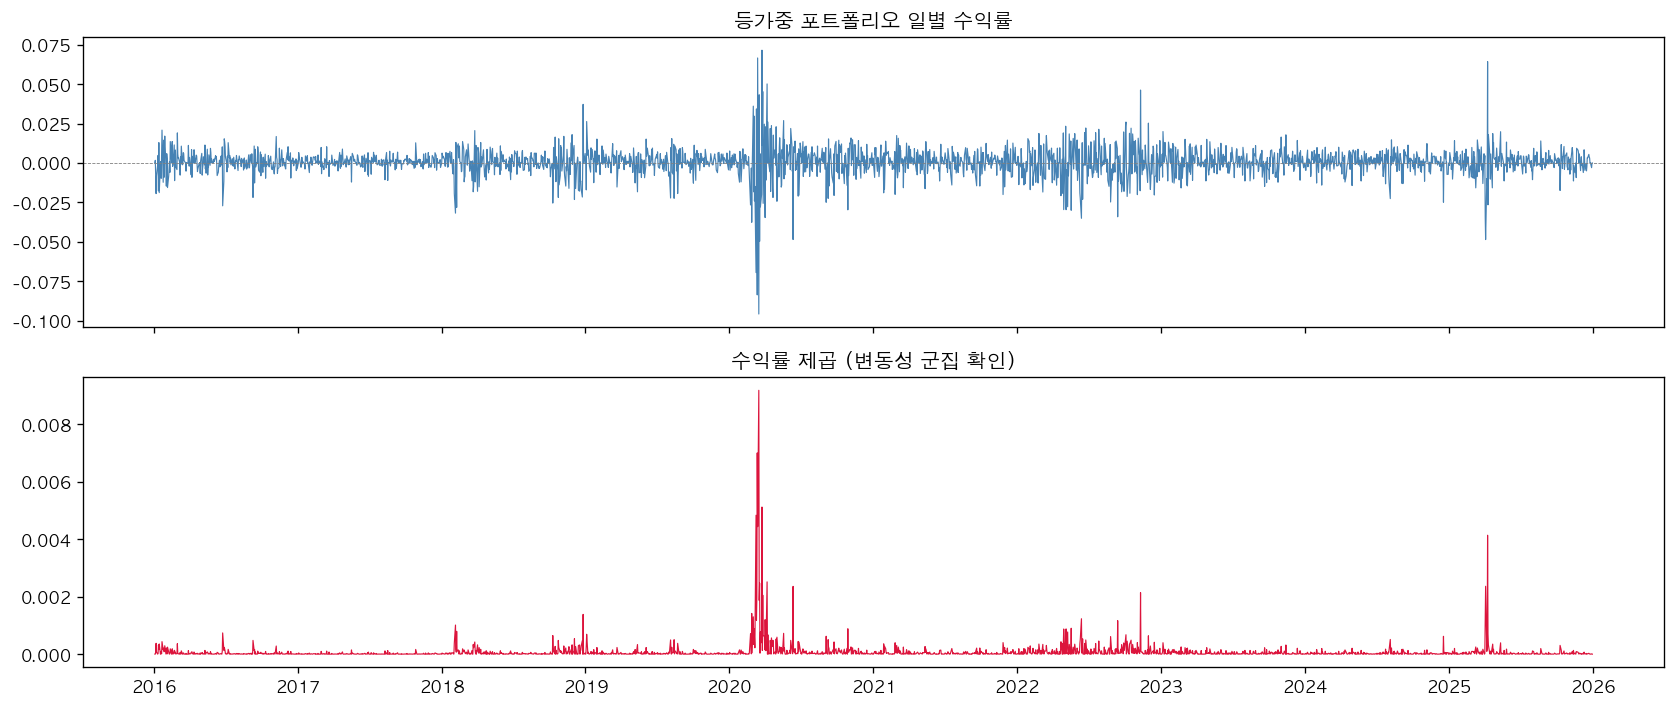

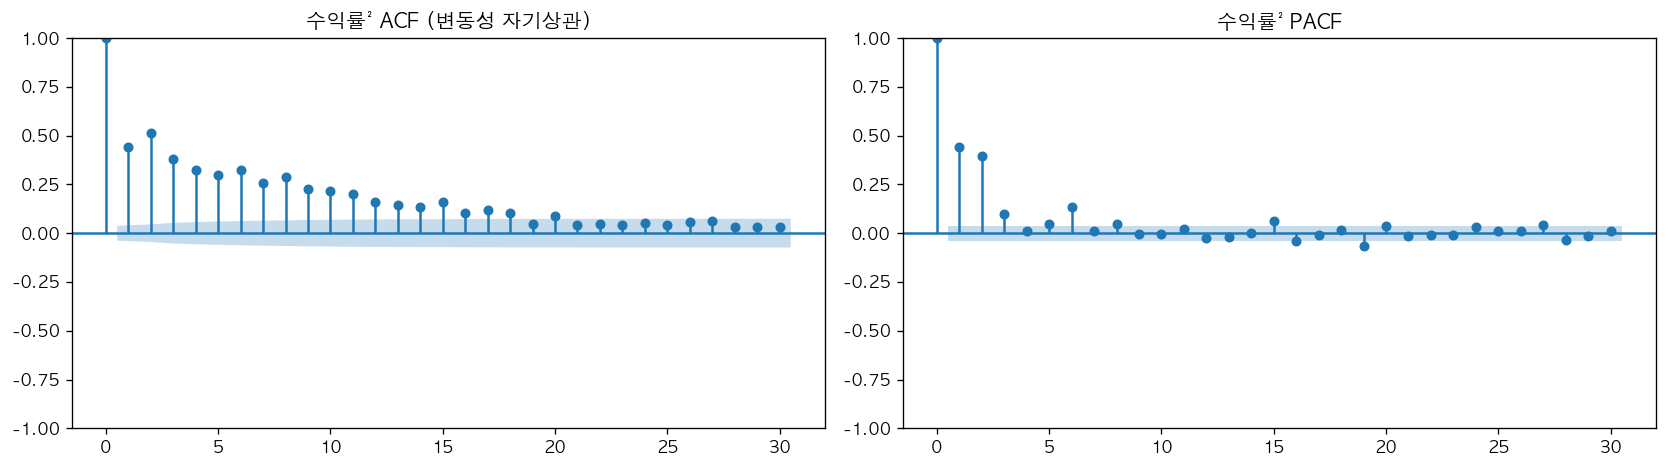

=== Engle ARCH LM Test ===


,lag,LM_stat,p_value,ARCH 효과
0,5,857.9671,0.0,YES ✓
1,10,891.9208,0.0,YES ✓
2,20,911.8062,0.0,YES ✓


In [15]:
# ── ARCH 효과 검정 ────────────────────────────────────────────
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 등가중 포트폴리오 수익률 (port_ew는 앞에서 정의됨)
ret = port_ew.dropna()
ret_sq = ret ** 2  # 수익률 제곱 → 변동성 대리변수

# 1. 수익률 & 수익률 제곱 시계열
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ret.index, ret.values, lw=0.7, color='steelblue')
axes[0].set_title('등가중 포트폴리오 일별 수익률', fontweight='bold')
axes[0].axhline(0, color='gray', lw=0.5, ls='--')
axes[1].plot(ret_sq.index, ret_sq.values, lw=0.7, color='crimson')
axes[1].set_title('수익률 제곱 (변동성 군집 확인)', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. 수익률 제곱의 ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ret_sq, lags=30, ax=axes[0], title='수익률² ACF (변동성 자기상관)')
plot_pacf(ret_sq, lags=30, ax=axes[1], title='수익률² PACF')
plt.tight_layout()
plt.show()

# 3. Engle's ARCH LM Test
print('=== Engle ARCH LM Test ===')
lm_results = []
for lag in [5, 10, 20]:
    lm_stat, p_val, f_stat, f_p = het_arch(ret, nlags=lag)
    lm_results.append({
        'lag': lag,
        'LM_stat': round(lm_stat, 4),
        'p_value': round(p_val, 4),
        'ARCH 효과': 'YES ✓' if p_val < 0.05 else 'NO'
    })
display(pd.DataFrame(lm_results))


#### ARCH 효과 검정 결과 해석

##### Engle ARCH LM Test 결과

| lag | LM_stat | p_value | 판정 |
|-----|---------|---------|------|
| 5  | 857.97 | 0.0000 | ARCH 효과 존재 ✓ |
| 10 | 891.92 | 0.0000 | ARCH 효과 존재 ✓ |
| 20 | 911.81 | 0.0000 | ARCH 효과 존재 ✓ |

**세 lag 모두 p=0.000, LM 통계량 800~900대** → ARCH 효과 매우 강하게 존재

---

##### 해석

**① 변동성 군집 확인**  
수익률 제곱의 ACF에서 여러 lag에 걸쳐 유의한 자기상관 → 큰 변동 뒤엔 큰 변동, 작은 변동 뒤엔 작은 변동이 이어지는 패턴이 뚜렷

**② OLS 가정 위반**  
잔차 분산이 시간에 따라 변함(이분산성) → 단순 OLS/선형회귀로 변동성을 예측하면 추정치가 비효율적

**③ 모델 선택 근거**  
- 변동성 예측(rv_neutral)이 목표 → **GARCH 계열 모델 사용 권장**
- 포트폴리오 최적화 시 공분산 추정에도 GARCH 기반 동적 공분산 행렬 활용 가능

> **결론**: ARCH 효과가 통계적으로 매우 강하게 확인됨 → Step 5 리스크 분석에서 GARCH 모델 도입 근거 마련

## 파생변수

In [17]:
# ── 파생변수 생성 (2-2 Feature Engineering) ─────────────────────
# EDA에서 사용한 port / ext / fred 변수를 그대로 사용

feat = pd.DataFrame(index=port.index)

# ① 변동성 기간구조
feat['VIX_contango']    = ext['^VIX3M'] / ext['^VIX'] - 1
feat['VIX_slope_9d_3m'] = ext['^VIX3M'] - ext['^VIX9D']
feat['VIX_slope_3m_6m'] = ext['^VIX6M'] - ext['^VIX3M']

# ② 테일 리스크
feat['SKEW_level'] = ext['^SKEW']
skew_roll = ext['^SKEW'].rolling(63)
feat['SKEW_zscore'] = (ext['^SKEW'] - skew_roll.mean()) / skew_roll.std()

# ③ 구리/금 경기 심리
feat['Cu_Au_ratio']     = ext['HG=F'] / ext['GC=F']
feat['Cu_Au_ratio_chg'] = feat['Cu_Au_ratio'].pct_change(21)

# ④ 신용 스프레드
feat['HY_spread']     = fred['BAMLH0A0HYM2']
feat['HY_spread_chg'] = fred['BAMLH0A0HYM2'].diff(5)

# ⑤ 수익률 곡선
feat['yield_curve']     = fred['T10Y2Y']
feat['yield_curve_inv'] = (fred['T10Y2Y'] < 0).astype(int)

# ⑥ 고용 지표
feat['claims_4wma']  = fred['ICSA'].rolling(20).mean()
icsa_roll = fred['ICSA'].rolling(260)
feat['claims_zscore'] = (fred['ICSA'] - icsa_roll.mean()) / icsa_roll.std()

# ⑦ 성장 지표
feat['WEI_level']      = fred['WEI']
feat['sahm_indicator'] = fred['SAHMREALTIME']

FEATURE_NAMES = list(feat.columns)
print(f'파생 변수 {len(FEATURE_NAMES)}개 생성 완료')
print(f'기간: {feat.index[0].date()} ~ {feat.index[-1].date()}')
print(f'결측치:\n{feat.isnull().sum()}')

# 저장
feat.to_csv(DATA / 'features.csv')
print(f'\n→ data/features.csv 저장 완료 ({feat.shape})')


파생 변수 15개 생성 완료
기간: 2016-01-01 ~ 2025-12-31
결측치:
VIX_contango         0
VIX_slope_9d_3m      0
VIX_slope_3m_6m      0
SKEW_level           0
SKEW_zscore         62
Cu_Au_ratio          0
Cu_Au_ratio_chg     21
HY_spread            0
HY_spread_chg        5
yield_curve          0
yield_curve_inv      0
claims_4wma         19
claims_zscore      259
WEI_level            0
sahm_indicator       0
dtype: int64

→ data/features.csv 저장 완료 ((2609, 15))


#### 파생변수 설명

---

##### 1. 변동성 및 리스크 지표 (VIX & SKEW)

시장의 공포·탐욕 지수라 불리는 VIX와 꼬리 리스크(Tail Risk)를 나타내는 SKEW를 활용한 지표들입니다.

| 변수 | 수식 | 해석 |
|------|------|------|
| `VIX_contango` | `^VIX3M / ^VIX - 1` | 3개월 만기 VIX와 현재 VIX의 비율. 정상 시장에선 원월물이 더 높은 '콘탱고' 상태이며, 이 값이 낮아지거나 음수(−)가 되면 단기 공포가 극도로 높아진 신호 |
| `VIX_slope_9d_3m` | `^VIX3M − ^VIX9D` | 초단기(9일) 대비 단기(3개월) 변동성 차이. 값이 작아질수록 단기 급락 위험이 반영 중 |
| `VIX_slope_3m_6m` | `^VIX6M − ^VIX3M` | 변동성 기간 구조의 장기 기울기 |
| `SKEW_level` | `^SKEW` 원시값 | 블랙 스완(예상치 못한 폭락)에 대비하는 옵션 비용 측정. 높을수록 시장 참여자들이 하락 리스크를 강하게 경계 |
| `SKEW_zscore` | `(SKEW − 63일 MA) / 63일 σ` | SKEW를 최근 3개월 기준으로 표준화. 현재 리스크 수준이 과거 평균 대비 얼마나 극단적인지 표현 |

---

##### 2. 경기 심리 및 모멘텀 지표 (Copper/Gold)

구리(경기 민감)와 금(안전 자산)의 가격 비율로 실물 경제의 활력을 측정합니다.

| 변수 | 수식 | 해석 |
|------|------|------|
| `Cu_Au_ratio` | `HG=F / GC=F` | 경기 회복기엔 구리↑·금 안정으로 지수 상승, 불황기엔 하락 |
| `Cu_Au_ratio_chg` | `pct_change(21)` | 이 비율의 최근 21일(약 1개월) 변화율(모멘텀) |

---

##### 3. 신용 및 채권 시장 지표 (Spread & Yield Curve)

기업 부도 위험과 채권 시장이 예상하는 경기 전망을 반영합니다.

| 변수 | 수식 | 해석 |
|------|------|------|
| `HY_spread` | `BAMLH0A0HYM2` | 하이일드 채권과 국채 간 금리 차이. 기업 자금 조달 여건 악화 시 급등 |
| `HY_spread_chg` | `diff(5)` | 최근 5일간 스프레드 변화량. 시장 충격을 빠르게 포착 |
| `yield_curve` | `T10Y2Y` | 10년물 − 2년물 금리차. 가장 유명한 경기침체 예고 지표 |
| `yield_curve_inv` | `(T10Y2Y < 0)` | 수익률 곡선 역전(장기 < 단기) 시 1을 반환하는 더미 변수 |

---

##### 4. 실물 경제 및 고용 지표 (Employment & Economy)

정부·기관이 발표하는 실제 경제 활동 수치들입니다.

| 변수 | 수식 | 해석 |
|------|------|------|
| `claims_4wma` | `ICSA.rolling(20).mean()` | 주간 신규 실업수당 청구 건수 이동평균. 고용 시장의 추세적 변화 반영 |
| `claims_zscore` | `(ICSA − 260일 MA) / 260일 σ` | 실업수당 청구를 1년 기준 표준화. 현재 고용 악화 속도의 심각성 표현 |
| `WEI_level` | `WEI` | 소매 판매·실업수당·전력 생산량 등 10개 지표를 합성한 주간 경제 지수. GDP보다 빠르게 실시간 경기 반영 |
| `sahm_indicator` | `SAHMREALTIME` | 실업률 최근 3개월 평균이 12개월 최저치보다 0.5%p↑이면 경기침체 진입으로 판단하는 Sahm Rule 지표 |

### 1. 기초 통계

In [50]:
# ── 파생변수 기초 통계 ────────────────────────────────────────
stats = feat.describe().T[['mean', 'std', 'min', 'max']]
stats['skewness'] = feat.skew()
stats['kurtosis'] = feat.kurt()
stats['결측치']   = feat.isnull().sum()
display(stats.round(4))

,mean,std,min,max,skewness,kurtosis,결측치
VIX_contango,0.1329,0.0945,-0.2558,3.589000e-01,-0.5248,0.5043,0
VIX_slope_9d_3m,2.8193,4.1030,-46.3200,1.249000e+01,-3.6909,25.9039,0
VIX_slope_3m_6m,1.3758,1.3413,-13.4100,3.590000e+00,-4.3693,32.8552,0
SKEW_level,135.2160,12.4524,110.3400,1.831200e+02,0.4815,0.0161,0
SKEW_zscore,0.0969,1.2228,-3.0705,3.828700e+00,0.1219,-0.3245,62
Cu_Au_ratio,0.0020,0.0003,0.0012,2.700000e-03,-0.2443,-0.9220,0
Cu_Au_ratio_chg,-0.0010,0.0641,-0.2389,3.254000e-01,0.4473,3.1437,21
HY_spread,4.1128,1.1729,2.5900,1.087000e+01,1.8429,4.1898,0
HY_spread_chg,-0.0082,0.2796,-2.0500,2.780000e+00,1.8332,20.6659,5
yield_curve,0.3829,0.5796,-1.0800,1.590000e+00,-0.2922,-0.5552,0


#### 주의해야 할 변수

##### 1. COVID-19 극단값 — 값이 튀는 변수

| 변수 | mean | max | 이상 원인 | 조치 |
|------|------|-----|-----------|------|
| `claims_4wma` | 376,225 | **5,288,250** | 2020년 3~4월 실업급여 폭발 (14배↑) | 로그 변환 `log(x)` |
| `claims_zscore` | -0.20 | **+16.01σ** | 동일 원인, 표준화해도 극단값 잔존 | ±5σ 클리핑 |
| `sahm_indicator` | 0.62 | **9.50** | COVID 실업률 급등 (정상 범위 0~0.5) | 99th 퍼센타일 winsorize |

> 세 변수 모두 **2020년 3~4월 단 수 주간**에 집중된 극단값입니다.  
> 처리 없이 모델에 투입하면 COVID 구간에 과적합될 수 있어요.

---

##### 2. 극단적 비대칭 — 꼬리가 두꺼운 변수

| 변수 | skew | kurtosis | 방향 | 원인 |
|------|------|----------|------|------|
| `VIX_slope_9d_3m` | **-3.69** | **25.40** | 왼쪽 꼬리 | 공포 급등 시 초단기 VIX가 원월물보다 훨씬 더 뛰어 음수로 폭락 |
| `VIX_slope_3m_6m` | **-4.32** | **31.50** | 왼쪽 꼬리 | 동일 구조, 더 심함 |
| `HY_spread_chg` | +2.00 | **22.79** | 오른쪽 꼬리 | 신용경색 시 스프레드 급등 (정상 시엔 거의 변화 없음) |
| `HY_spread` | +2.44 | 9.40 | 오른쪽 꼬리 | COVID·금융위기 스파이크 |

> kurtosis > 10은 정규분포 대비 **극단값 빈도가 매우 높음**을 의미해요.  
> 선형 모델 사용 시 1~99th 퍼센타일 **winsorize** 권장.

---

##### 3. 스케일 차이 — 단위가 다른 변수

| 변수 | 범위 | 비고 |
|------|------|------|
| `claims_4wma` | 197,500 ~ 5,288,250 | 나머지 변수와 스케일이 수만 배 차이 |
| `SKEW_level` | 110 ~ 183 | 절대값이 크지만 변동폭 자체는 무난 |
| `Cu_Au_ratio` | 0.0012 ~ 0.0027 | 절대값이 매우 작음 |

> `StandardScaler` 또는 `MinMaxScaler` 적용 전에 `claims_4wma`는 **반드시 로그 변환** 선행 필요.

In [51]:
# # 1. 변동성 위험 프리미엄 (VIX는 % 단위이므로 scale 조정 필요할 수 있음)
# feat['vol_premium'] = external_prices['^VIX'] - (rv_neutral * 100)

# # 2. 신용 스프레드 표준화
# hy_roll = external_prices['BAMLH0A0HYM2'].rolling(63)
# feat['HY_spread_zscore'] = (external_prices['BAMLH0A0HYM2'] - hy_roll.mean()) / hy_roll.std()

# # 3. 매크로 모멘텀 (WEI 4주 변화량)
# feat['WEI_diff_4w'] = external_prices['WEI'].diff(4)

# # 4. 자산간 상관관계 (예: 스파이와 국채)
# # 주식(SPY)과 채권(TLT) 데이터가 external_prices에 있다고 가정 시
# feat['stock_bond_corr'] = ext_ret['SPY'].rolling(21).corr(ext_ret['TLT'])

# # 5. VIX 급증 속도
# feat['VIX_speed'] = external_prices['^VIX'].diff(5)

#### 결측치 발생 원인

| 변수 | 결측 원인 | 결측 발생 구간 |
|------|-----------|----------------|
| `SKEW_zscore` | 63일 롤링 윈도우 워밍업 | 초기 63거래일 |
| `Cu_Au_ratio_chg` | 21일 pct_change 워밍업 | 초기 21거래일 |
| `claims_4wma` | 20일 롤링 MA 워밍업 | 초기 20거래일 |
| `claims_zscore` | **260일 롤링 윈도우 워밍업** | 초기 260거래일 (≈ 1년) |
| `WEI_level`, `sahm_indicator` | FRED 발표 시작 시점 차이 | 데이터 시작 전 구간 |
| `HY_spread_chg` | 5일 diff 워밍업 | 초기 5거래일 |

이를 처리한 후 **실제 분석에 사용하는 데이터는 2017-01-01 ~ 2025-12-31** 입니다.

In [ ]:
# ── 결측치 처리 ───────────────────────────────────────────────
ANALYSIS_START = '2017-01-01'
ANALYSIS_END   = '2025-12-31'

print('=== 처리 전 결측치 ===')
print(feat.isnull().sum())

# 1. FRED forward-fill 보완 (주간·월간 갭)
feat_clean = feat.copy()
feat_clean = feat_clean.ffill().bfill()

# 2. 롤링 워밍업 구간 제거
feat_clean = feat_clean.dropna()

# 3. 분석 기간 고정 (2017-01-01 ~ 2025-12-31)
feat_clean = feat_clean.loc[ANALYSIS_START:ANALYSIS_END]

print(f'\n=== 처리 후 결측치 ===')
print(feat_clean.isnull().sum())
print(f'\n유효 기간: {feat_clean.index[0].date()} ~ {feat_clean.index[-1].date()}')
print(f'유효 행 수: {len(feat_clean)} (원본 대비 제거: {len(feat) - len(feat_clean)}행)')

# 저장
feat_clean.to_csv(DATA / 'features_clean.csv')
print(f'\n→ data/features_clean.csv 저장 완료 ({feat_clean.shape})')

=== 처리 전 결측치 ===
VIX_contango         0
VIX_slope_9d_3m      0
VIX_slope_3m_6m      0
SKEW_level           0
SKEW_zscore         62
Cu_Au_ratio          0
Cu_Au_ratio_chg     21
HY_spread            0
HY_spread_chg        5
yield_curve          0
yield_curve_inv      0
claims_4wma         19
claims_zscore      259
WEI_level            0
sahm_indicator       0
dtype: int64

=== 처리 후 결측치 ===
VIX_contango       0
VIX_slope_9d_3m    0
VIX_slope_3m_6m    0
SKEW_level         0
SKEW_zscore        0
Cu_Au_ratio        0
Cu_Au_ratio_chg    0
HY_spread          0
HY_spread_chg      0
yield_curve        0
yield_curve_inv    0
claims_4wma        0
claims_zscore      0
WEI_level          0
sahm_indicator     0
dtype: int64

유효 기간: 2017-01-02 ~ 2025-12-31
유효 행 수: 2348 (원본 대비 제거: 261행)

→ data/features_clean.csv 저장 완료 ((2348, 15))


### 파생변수 시계열 시각화 (카테고리별)

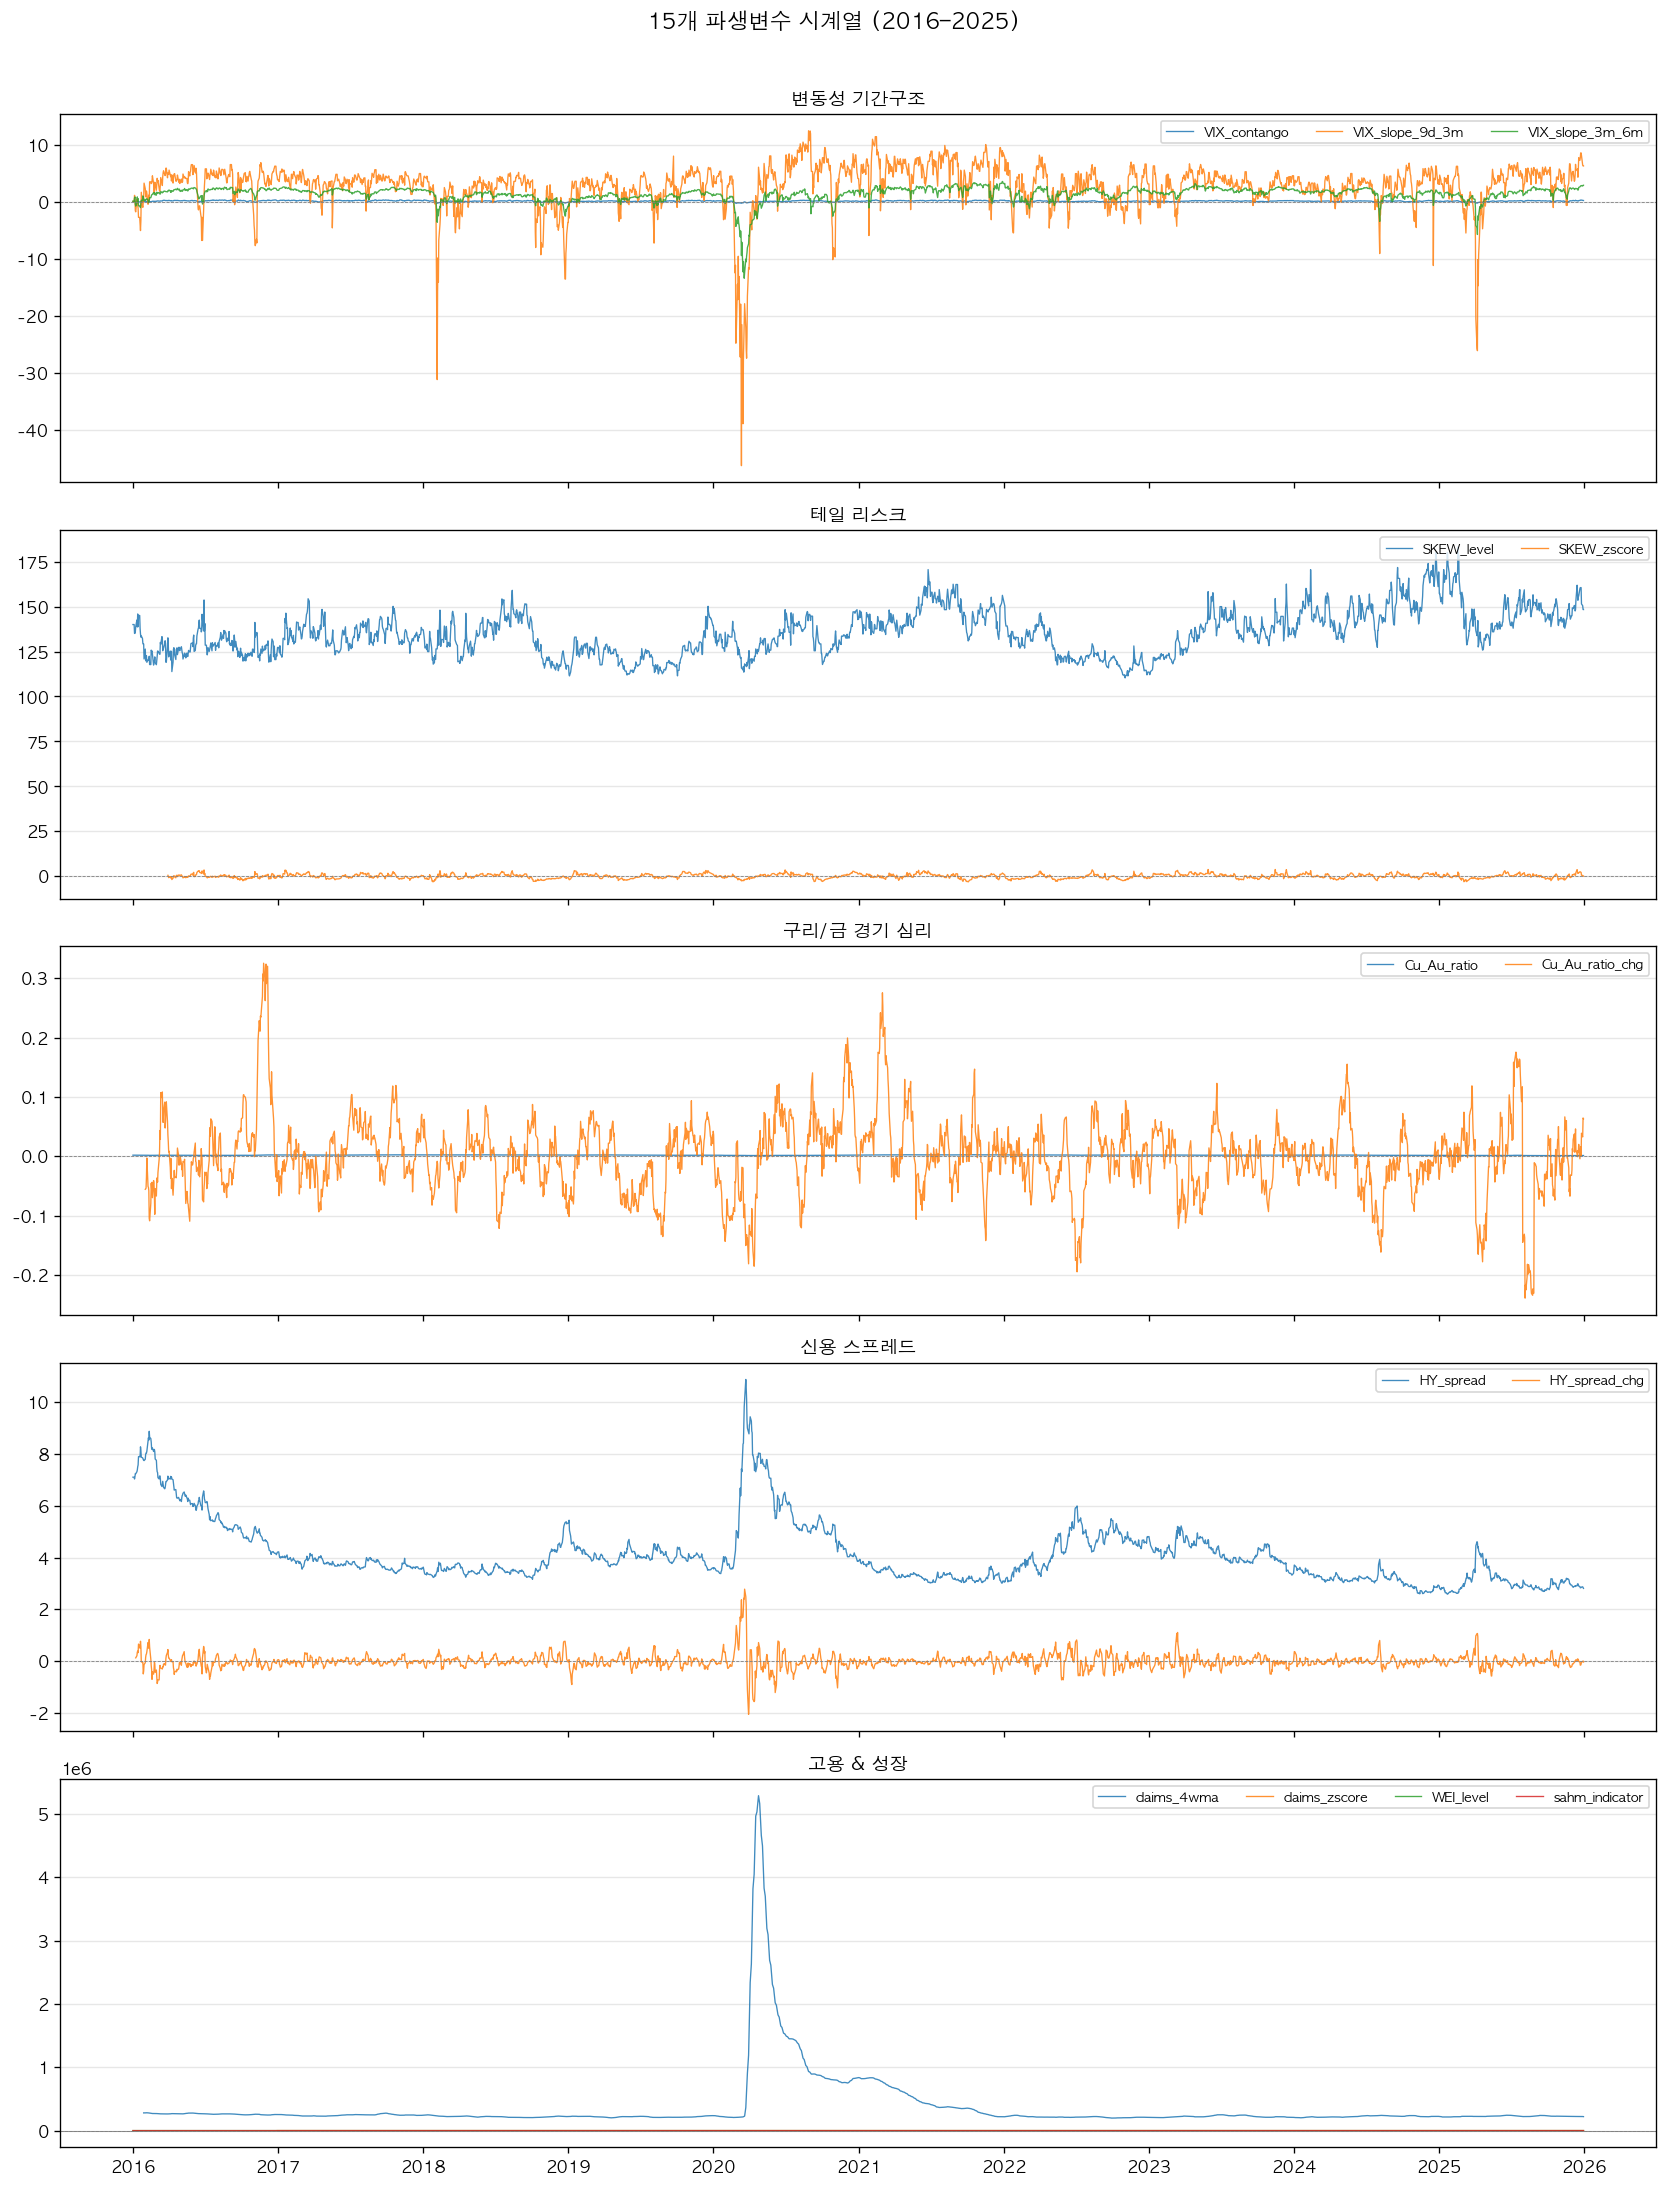

→ images/feat_timeseries.png 저장


In [57]:
# ── 파생변수 시계열 시각화 (카테고리별 5-panel) ─────────────────
groups = {
    '변동성 기간구조': ['VIX_contango', 'VIX_slope_9d_3m', 'VIX_slope_3m_6m'],
    '테일 리스크':     ['SKEW_level', 'SKEW_zscore'],
    '구리/금 경기 심리': ['Cu_Au_ratio', 'Cu_Au_ratio_chg'],
    '신용 스프레드':   ['HY_spread', 'HY_spread_chg'],
    '고용 & 성장':     ['claims_4wma', 'claims_zscore', 'WEI_level', 'sahm_indicator'],
}

colors = ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
fig, axes = plt.subplots(len(groups), 1, figsize=(14, 18), sharex=True)

for ax, (title, cols), color in zip(axes, groups.items(), colors):
    for col in cols:
        ax.plot(feat.index, feat[col], lw=0.8, label=col, alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.legend(loc='upper right', fontsize=8, ncol=len(cols))
    ax.grid(axis='y', alpha=0.3)

# 수익률 곡선 & 역전 더미는 별도 표시 (yield_curve_inv)
axes[-1].axhline(0, color='gray', lw=0.5)

fig.suptitle('15개 파생변수 시계열 (2016–2025)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMG / 'feat_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()
print('→ images/feat_timeseries.png 저장')


### 수익률 곡선 (yield_curve & 역전 더미)

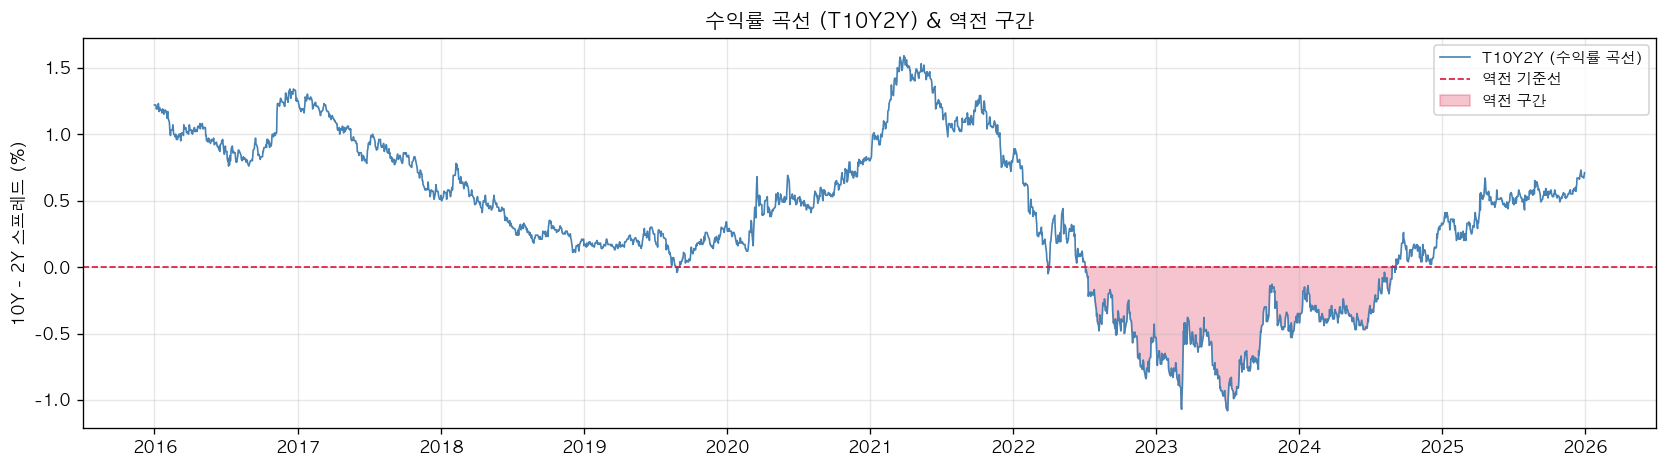

역전 일수: 566일 / 전체 2609일 (21.7%)


In [54]:
# ── 수익률 곡선 역전 타임라인 ───────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 4))
yc = feat['yield_curve'].dropna()
ax1.plot(yc.index, yc.values, lw=1.0, color='steelblue', label='T10Y2Y (수익률 곡선)')
ax1.axhline(0, color='crimson', lw=1.0, ls='--', label='역전 기준선')
ax1.fill_between(yc.index, yc.values, 0,
                 where=(yc.values < 0), color='crimson', alpha=0.25, label='역전 구간')
ax1.set_title('수익률 곡선 (T10Y2Y) & 역전 구간', fontweight='bold')
ax1.set_ylabel('10Y - 2Y 스프레드 (%)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

inv_days = feat['yield_curve_inv'].sum()
print(f'역전 일수: {int(inv_days)}일 / 전체 {len(feat['yield_curve_inv'].dropna())}일 ({inv_days/len(feat['yield_curve_inv'].dropna())*100:.1f}%)')


### 파생변수 상관관계 히트맵

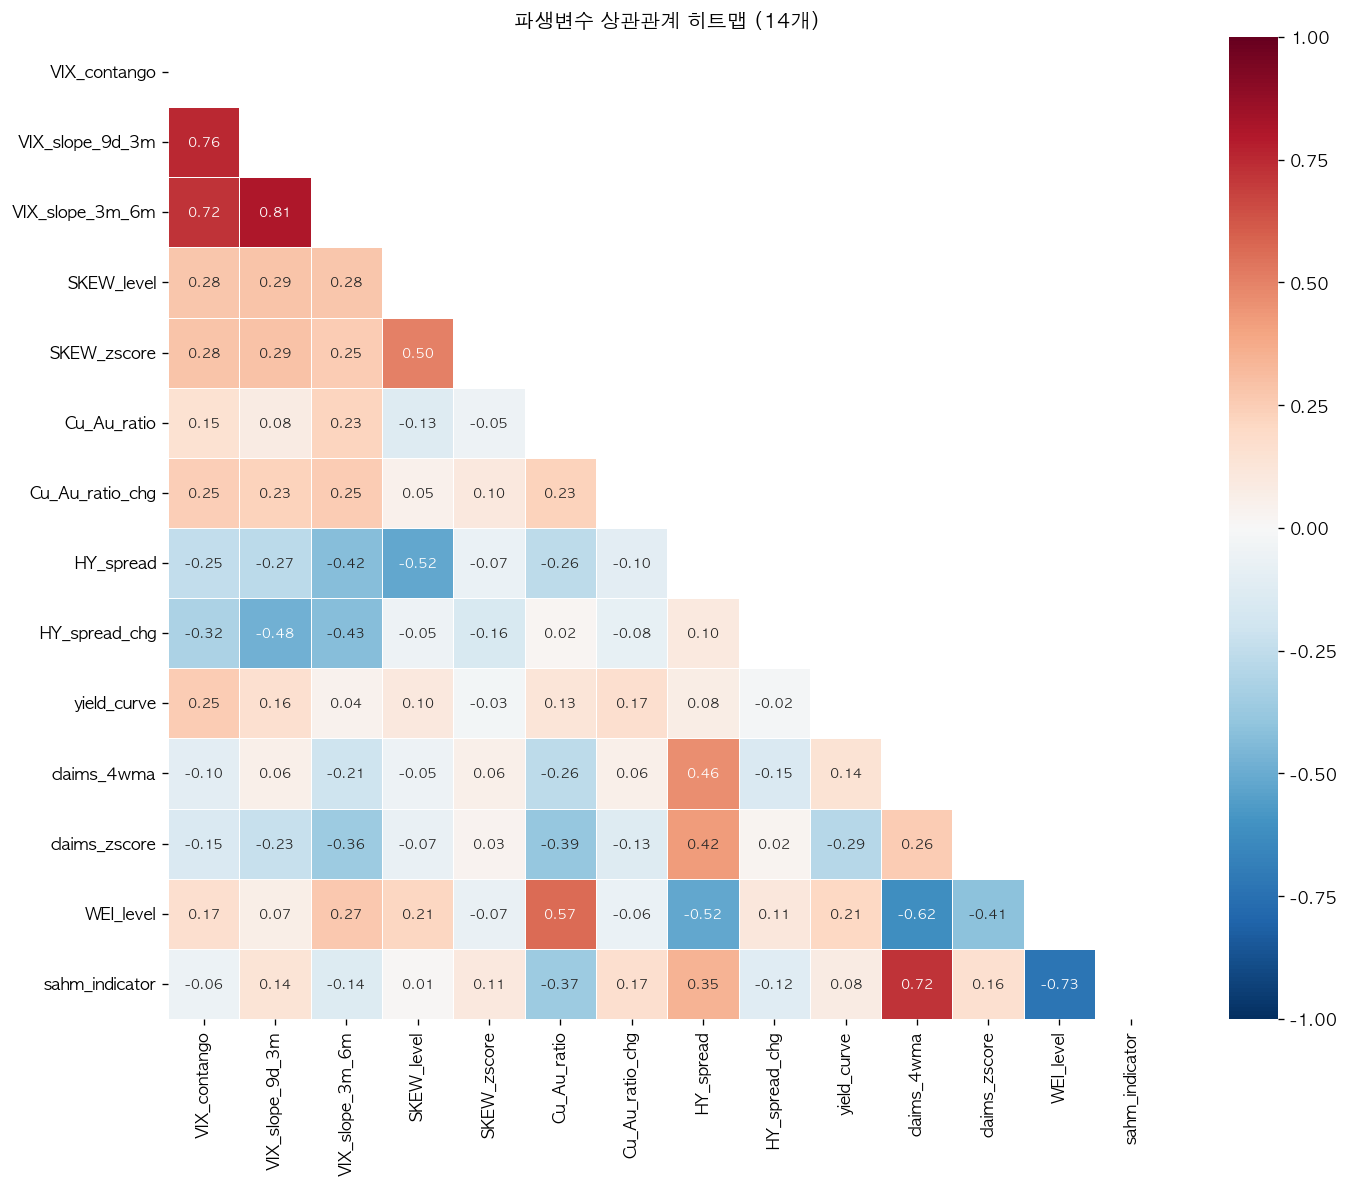

→ images/feat_corr_heatmap.png 저장


In [55]:
# ── 파생변수 간 상관관계 히트맵 ─────────────────────────────────
feat_corr = feat.drop(columns=['yield_curve_inv']).corr()  # 더미 제외

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(feat_corr, dtype=bool))
sns.heatmap(
    feat_corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, annot_kws={'size': 8}
)
ax.set_title('파생변수 상관관계 히트맵 (14개)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(IMG / 'feat_corr_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('→ images/feat_corr_heatmap.png 저장')


### 파생변수 ↔ 등가중 포트폴리오 수익률 상관관계

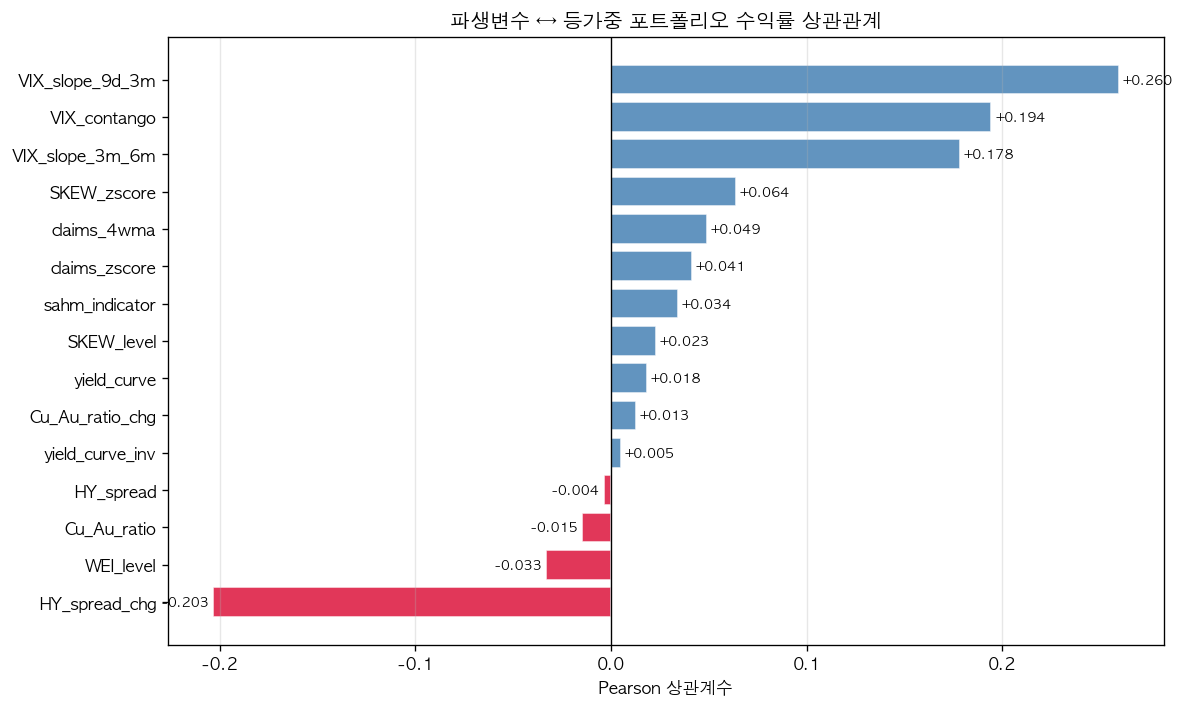

→ images/feat_corr_portew.png 저장

=== 파생변수 생성 & EDA 완료 ===


In [56]:
# ── 파생변수 ↔ port_ew 상관관계 막대 차트 ──────────────────────
corr_with_ew = (
    feat.join(port_ew.rename('port_ew'), how='inner')
        .corr()['port_ew']
        .drop('port_ew')
        .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['crimson' if v < 0 else 'steelblue' for v in corr_with_ew.values]
ax.barh(corr_with_ew.index, corr_with_ew.values, color=colors_bar, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('파생변수 ↔ 등가중 포트폴리오 수익률 상관관계', fontweight='bold')
ax.set_xlabel('Pearson 상관계수')
ax.grid(axis='x', alpha=0.3)

for i, (val, lbl) in enumerate(zip(corr_with_ew.values, corr_with_ew.index)):
    ax.text(val + (0.002 if val >= 0 else -0.002), i,
            f'{val:+.3f}', va='center', ha=('left' if val >= 0 else 'right'), fontsize=8)

plt.tight_layout()
plt.savefig(IMG / 'feat_corr_portew.png', dpi=120, bbox_inches='tight')
plt.show()
print('→ images/feat_corr_portew.png 저장')
print('\n=== 파생변수 생성 & EDA 완료 ===')
